<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        📚 Predicting Student Test Scores 🎓
    </h1>
</div>

# 📂 Overview

* **Background** <br>
  Student academic performance is influenced by a combination of **study behavior, learning environment, lifestyle habits, and course difficulty**. Understanding how these factors contribute to exam outcomes can help educators and students improve learning strategies, resource allocation, and academic planning.

* **Goal of the Project** <br>
  Using the provided dataset, the objective is to **predict students’ exam scores** based on demographic information, study habits, sleep patterns, learning methods, and academic environment factors.

**Key Features**

**Target Variable**

* `exam_score`: *Final exam score achieved by the student (continuous numeric value).*

**General Feature Characteristics**

**Student Demographics**

* `student_id`: Unique identifier for each student.
* `age`: Age of the student (numeric).
* `gender`: Gender of the student (categorical).
* `course`: Academic program enrolled (e.g., diploma, bca, b.sc).

**Study Behavior & Attendance**

* `study_hours`: Average daily study hours.
* `class_attendance`: Percentage of class attendance.
* `study_method`: Preferred study approach (e.g., coaching, online videos).

**Learning Environment**

* `internet_access`: Availability of internet access (yes / no).
* `facility_rating`: Quality of academic facilities (low / medium / high).
* `exam_difficulty`: Perceived difficulty of the exam (easy / moderate / hard).

**Lifestyle & Sleep**

* `sleep_hours`: Average sleep duration per day.
* `sleep_quality`: Self-reported sleep quality (poor / average / good).

**Feature Types Summary**

* **Numerical:** `age`, `study_hours`, `class_attendance`, `sleep_hours`, `exam_score`
* **Categorical:** `gender`, `course`, `study_method`, `facility_rating`, `exam_difficulty`, `sleep_quality`, `internet_access`

**Files Provided**

* `exam_score.csv` (or equivalent): Dataset containing both features and target variable.

Source:

[Kaggle – Exam Score Prediction Dataset](https://www.kaggle.com/datasets/kundanbedmutha/exam-score-prediction-dataset)

[Playground Series S6E1 - Predicting Student Test Scores](https://www.kaggle.com/competitions/playground-series-s6e1)

**Project Objective**

The primary objective of this notebook is to **perform exploratory data analysis (EDA) and build regression models to predict student exam scores**.

Key components of the approach include:

* **Exploratory Data Analysis (EDA):**

  * Analyze score distribution.
  * Study relationships between study habits, sleep, and exam performance.
  * Detect outliers (e.g., extreme study hours or attendance).

* **Feature Engineering:**

  * Encode categorical variables.
  * Scale numerical features.
  * Create interaction features (e.g., study_hours × sleep_quality).

* **Modeling:**

  * Train model LGBM.

* **Evaluation Framework:** <br>

  * Cross-validation (K-Fold).
  * Metrics: **RMSE**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin > pip_log_pingouin.txt 2>&1

In [2]:
# =====================================================
# Core Data Manipulation
# =====================================================
import pandas as pd              # DataFrame manipulation
import numpy as np               # Numerical operations

# =====================================================
# Visualization & Explainability
# =====================================================
import matplotlib.pyplot as plt  # Base plotting
import seaborn as sns            # Statistical visualization
import shap                      # Model explainability (SHAP values)

# =====================================================
# Jupyter Display Utilities
# =====================================================
from IPython.display import display, HTML  # Rich output in notebooks

# =====================================================
# Machine Learning - Model Selection & Metrics
# =====================================================
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import LabelEncoder

# =====================================================
# Feature Engineering Utilities
# =====================================================
from itertools import combinations  # Create interaction features

# =====================================================
# Hyperparameter Optimization
# =====================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Reduce Optuna noise

# =====================================================
# Statistical Analysis
# =====================================================
from scipy.signal import find_peaks                 # Peak detection (EDA)
from scipy.stats import (
    skew, kurtosis,                                 # Distribution shape
    probplot,                                       # Q-Q plot
    chi2_contingency,                               # Chi-square test
    kruskal,                                        # Non-parametric ANOVA
    levene,                                         # Variance homogeneity
    ttest_ind,                                      # Independent t-test
    mannwhitneyu                                    # Non-parametric 2-sample test
)

import scikit_posthocs as sp                        # Post-hoc tests
import pingouin as pg                               # Effect size, stats utils

# =====================================================
# Statistical Modeling (ANOVA / OLS)
# =====================================================
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =====================================================
# Machine Learning Models
# =====================================================
from lightgbm import LGBMRegressor

# =====================================================
# System, Logging & Utilities
# =====================================================
import logging
import sys
import os
import time

# =====================================================
# Notebook Settings
# =====================================================
import warnings
warnings.filterwarnings("ignore")        # Suppress warnings for clean output

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [3]:
class config:
    """
    Global configuration class for:
    - Reproducibility
    - Data paths
    - Logging
    - Data utilities
    - Model hyperparameters
    """

    # ========= Reproducibility ========
    # Fix random seed for all experiments
    random_state = 42
    # Number of folds for cross-validation
    fold = 5
    # Target column name
    target_feature = "exam_score"

    # ========= Data Paths =========
    original_data = "/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv"
    train_data = "/kaggle/input/playground-series-s6e1/train.csv"
    test_data = "/kaggle/input/playground-series-s6e1/test.csv"

    # ========= Logger =========
    @staticmethod
    def setup_notebook_logger(level=logging.DEBUG):
        """
        Create a clean logger for Jupyter Notebook.
        - Prevent duplicated logs when re-running cells
        - Output logs to stdout
        """
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False   # Prevent logs from propagating to the root logger
        logger.handlers.clear()

        # Clear existing handlers (in case the notebook cell is run multiple times)
        logger.handlers.clear()

        handler = logging.StreamHandler(sys.stdout)
        formatter = logging.Formatter(
            # fmt="{asctime} | {levelname:<7} | {message}",
            fmt="{asctime} | {levelname} | {message}",
            datefmt="%Y-%m-%d %H:%M:%S",
            style="{"
        )
        handler.setFormatter(formatter)
        logger.addHandler(handler)

        return logger

    # ========= Data Utils =========
    @staticmethod
    def read_csv_safe(path, logger, encodings=("utf-8", "latin1", "cp1252", "ISO-8859-1")):
        """
        Safely read CSV file by trying multiple encodings.
        Log progress and failures.
        """
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded file with encoding: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed with encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("CSV file is empty.")
                return None
            except pd.errors.ParserError:
                logger.error("CSV parsing error. Please check file format.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error while reading CSV: {e}")
                return None
        logger.error("Unable to read file with all provided encodings.")
        return None

    @staticmethod
    def clean_columns(df):
        """
        Standardize column names:
        - Strip spaces
        - Remove inner whitespaces
        """
        df.columns = (df.columns.str.strip().str.replace(r"\s+", "", regex=True))
        return df

    @staticmethod
    def reduce_mem_usage(df):
        """
        Reduce memory usage by downcasting numeric types.
        """
        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object and col_type.name != 'category':
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                else:
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")
        return df

    @staticmethod
    def memory_report(df):
        """
        Return dataframe memory usage in MB.
        """
        return df.memory_usage(deep=True).sum() / 1024**2

    # ========= LightGBM Parameters =========
    # CPU-optimized configuration
    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 25000,
        "max_depth": 8,
        "num_leaves": 500,
        "learning_rate": 0.04,
        "subsample": 0.8,
        "subsample_freq": 1,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.01,
        "reg_lambda": 1.0,
        "random_state": random_state,
        "n_jobs": -1,
        "verbose": -1
    }

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [4]:
# Initialize notebook logger
logger = config.setup_notebook_logger()
# Load datasets safely
df_original = config.read_csv_safe(config.original_data, logger).pipe(config.clean_columns)
df_train = config.read_csv_safe(config.train_data, logger).pipe(config.clean_columns)
df_test = config.read_csv_safe(config.test_data, logger).pipe(config.clean_columns)

2026-01-02 12:23:08 | INFO | Loaded file with encoding: utf-8 | Shape: (20000, 13)
2026-01-02 12:23:09 | INFO | Loaded file with encoding: utf-8 | Shape: (630000, 13)
2026-01-02 12:23:09 | INFO | Loaded file with encoding: utf-8 | Shape: (270000, 12)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
# Display few rows of each dataset
logger.info("Train Data Preview:")
display(df_train.tail())

logger.info("Origin Data Preview:")
display(df_original.head())

logger.info("Test Data Preview:")
display(df_test.head())

2026-01-02 12:23:09 | INFO | Train Data Preview:


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100
629999,629999,18,other,b.tech,3.94,75.3,yes,5.8,poor,online videos,low,easy,37.200


2026-01-02 12:23:09 | INFO | Origin Data Preview:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


2026-01-02 12:23:09 | INFO | Test Data Preview:


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [6]:
# Display information about the DataFrames
logger.info("Train Data Info:")
df_train.info()

logger.info("Origin Data Info:")
df_original.info()

logger.info("Test Data Info:")
df_test.info()

2026-01-02 12:23:09 | INFO | Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
2026-01-02 12:23:10 | INFO | Origin Data Info:
<class 'panda

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The **training dataset** contains **630,000 samples** with **13 columns**, including the target variable `exam_score`.
* The **original dataset** contains **20,000 samples** with the same 13 columns, serving as the raw source data.
* The **test dataset** includes **270,000 samples** with **12 columns**, excluding the target variable and ready for prediction.

Overall, the train and test datasets are significantly larger than the original dataset, indicating that they are likely **synthetically expanded or augmented** versions of the original data.

**Feature Overview**

* All datasets share a consistent schema, covering:

  * **Numerical features:**
    `age`, `study_hours`, `class_attendance`, `sleep_hours`
  * **Categorical features:**
    `gender`, `course`, `internet_access`, `sleep_quality`, `study_method`, `facility_rating`, `exam_difficulty`
* The target variable `exam_score` is a **continuous numeric variable (float64)**, confirming that this is a **regression problem**.

The combination of behavioral, lifestyle, and academic environment features suggests strong potential for feature interactions.

**Data Completeness**

* There are **no missing values** across the training, test, and original datasets.
* All columns have consistent non-null counts, which simplifies preprocessing and modeling pipelines.
* Data types are appropriate for modeling; however, **categorical features are currently stored as `object`**, which may increase memory usage and require encoding.

**Memory Usage and Optimization Opportunities**

* The training dataset consumes approximately **62.5 MB**, while the test dataset uses **24.7 MB**.
* Given the dataset size, **memory optimization is recommended**, such as:

  * Converting categorical `object` columns to `category` dtype.
  * Downcasting numerical columns where applicable.
* The identifier columns (`id`, `student_id`) **do not carry predictive information** and should be dropped before modeling.

In [7]:
num_features = ["age", "study_hours", "class_attendance", "sleep_hours"]
cat_features = ["gender", "course", "internet_access", "sleep_quality", "study_method", 
                "facility_rating", "exam_difficulty"]

# Drop columns id
df_train.drop(columns="id", axis=1, inplace=True)
list_test_id = df_test["id"].copy().to_list()
df_test.drop("id", axis=1, inplace=True)
df_original.drop("student_id", axis=1, inplace=True)

## Descriptive Insights from Dataset Statistics

In [8]:
cm = sns.light_palette("blue", as_cmap=True)
logger.info("Train data describe:")
display(df_train[num_features].describe().T.style.background_gradient(cmap=cm))

logger.info("Original data describe:")
display(df_original[num_features].describe().T.style.background_gradient(cmap=cm))

logger.info("Test data describe:")
display(df_test[num_features].describe().T.style.background_gradient(cmap=cm))

2026-01-02 12:23:10 | INFO | Train data describe:


,count,mean,std,min,25%,50%,75%,max
age,630000.000000,20.545821,2.260238,17.000000,19.000000,21.000000,23.000000,24.000000
study_hours,630000.000000,4.002337,2.359880,0.080000,1.970000,4.000000,6.050000,7.910000
class_attendance,630000.000000,71.987261,17.430098,40.600000,57.000000,72.600000,87.200000,99.400000
sleep_hours,630000.000000,7.072758,1.744811,4.100000,5.600000,7.100000,8.600000,9.900000


2026-01-02 12:23:10 | INFO | Original data describe:


,count,mean,std,min,25%,50%,75%,max
age,20000.000000,20.473300,2.284458,17.000000,18.000000,20.000000,22.000000,24.000000
study_hours,20000.000000,4.007603,2.308313,0.080000,2.000000,4.040000,6.000000,7.910000
class_attendance,20000.000000,70.017365,17.282262,40.600000,55.100000,69.900000,85.000000,99.400000
sleep_hours,20000.000000,7.008560,1.732090,4.100000,5.500000,7.000000,8.500000,9.900000


2026-01-02 12:23:10 | INFO | Test data describe:


,count,mean,std,min,25%,50%,75%,max
age,270000.000000,20.544137,2.260452,17.000000,19.000000,21.000000,23.000000,24.000000
study_hours,270000.000000,4.003878,2.357741,0.080000,1.980000,4.010000,6.050000,7.910000
class_attendance,270000.000000,71.982509,17.414695,40.600000,57.000000,72.600000,87.200000,99.400000
sleep_hours,270000.000000,7.072070,1.745513,4.100000,5.600000,7.100000,8.600000,9.900000


**Feature Highlights**

* **Age**:
  Mean around **20.5 years**, ranging from **17 to 24**, with a tight interquartile range (19–23) → the dataset focuses on a **young, relatively homogeneous student population**, typical of undergraduate-level education.

* **Study Hours**:
  Average around **4.0 hours/day**, with values ranging from **0.08 to 7.91 hours** → shows **substantial variability in study habits**, from minimal studying to highly dedicated learners.

* **Class Attendance**:
  Mean approximately **70–72%**, spanning from **~41% to ~99%** → indicates a **wide spread in attendance behavior**, which is likely a strong predictor of academic performance.
  The relatively high standard deviation (~17.4) highlights significant differences in student engagement.

* **Sleep Hours**:
  Average close to **7.0 hours/day**, with a range from **4.1 to 9.9 hours** → most students fall within a **healthy sleep window**, but there is still notable variation that may impact exam outcomes.

**Cross-Dataset Consistency**

* The **train, origin, and test datasets exhibit highly consistent distributions** across all numerical features:

  * Means, medians, percentiles, and ranges are closely aligned.
  * No noticeable distributional drift is observed.
* This consistency suggests that:

  * The train and test sets are well-aligned.
  * Models trained on the training data should generalize reliably to the test data.

**Distribution Characteristics**

* **Study hours** and **class attendance** show **higher dispersion** compared to age and sleep hours, indicating stronger behavioral variability.
* **Age** is tightly distributed with low variance, making it a secondary but stable explanatory feature.
* None of the numerical features exhibit extreme outliers, as min–max values remain within realistic and interpretable bounds.

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
logger.info("Train Data describe:")
display(df_train[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

logger.info("Test Data describe:")
display(df_test[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

logger.info("Original Data describe:")
display(df_original[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-01-02 12:23:10 | INFO | Train Data describe:


,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


2026-01-02 12:23:11 | INFO | Test Data describe:


,count,unique,top,freq
gender,270000,3,male,90682
course,270000,7,b.tech,56461
internet_access,270000,2,yes,248671
sleep_quality,270000,3,good,91754
study_method,270000,5,coaching,56698
facility_rating,270000,3,medium,91816
exam_difficulty,270000,3,moderate,151656


2026-01-02 12:23:11 | INFO | Original Data describe:


,count,unique,top,freq
gender,20000,3,other,6726
course,20000,7,bca,2902
internet_access,20000,2,yes,16988
sleep_quality,20000,3,average,6694
study_method,20000,5,self-study,4079
facility_rating,20000,3,medium,6760
exam_difficulty,20000,3,moderate,9878


**Feature Highlights**

* **Gender:**
  3 categories across all datasets.

  * Train is slightly dominated by **“other”**, while Test is more **male-heavy**.
  * Differences exist but not extreme → **acceptable imbalance**.

* **Course:**
  7 distinct academic programs in all datasets.

  * **`b.tech`** is the most frequent in Train and Test, while **`bca`** dominates the Original dataset.
  * Despite different top categories, overall structure is consistent → **no critical category shift**.

* **Internet Access:**
  Binary feature with **“yes” overwhelmingly dominant** across Train, Test, and Original.

  * Strong imbalance → likely an important but low-variance predictor.

* **Sleep Quality:**
  3 levels present in all datasets.

  * Train leans toward **“poor”**, Test toward **“good”**, Original toward **“average”**.
  * Category proportions vary slightly but remain realistic → **mild distribution variation**.

* **Study Method:**
  5 distinct categories.

  * **“coaching”** is the most frequent in both Train and Test.
  * Original dataset shows higher **self-study** representation.
  * Pattern suggests behavioral diversity but **no missing categories**.

* **Facility Rating:**
  3 categories with **“medium” consistently dominant** across all datasets.

  * Well-balanced and stable feature.

* **Exam Difficulty:**
  3 categories, with **“moderate” clearly dominant** in Train, Test, and Original.

  * Highly consistent distribution → **strongly stable categorical feature**.

**Key Highlights**

* All categorical features maintain **the same number of unique categories** across Train, Test, and Original datasets.
* No unseen categories appear in the Test set → **safe encoding for modeling**.
* Most features show **consistent dominant categories**, indicating **no major distribution shift**.
* The most imbalanced variables are:

  * **Internet access**
  * **Exam difficulty**
  * **Facility rating**

  These variables may exert **strong influence during model training** and should be monitored for bias effects.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [10]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left")))
        except ImportError:
            logging.error(missing_df.to_string(index=False))

        logging.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")

datasets = [
    ("Train Set", df_train),
    ("Test Set", df_test),
    ("Original Set", df_original),
]

for name, df in datasets:
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df, dataset_name=name)
    logger.info("-" * 60)

logger.info("Completed checking for NULL values across datasets.")

2026-01-02 12:23:11 | INFO | Start checking NULL values
2026-01-02 12:23:11 | INFO | Checking missing values for Train Set...
2026-01-02 12:23:14 | INFO | No missing values detected in 630,000 rows.
2026-01-02 12:23:14 | INFO | ------------------------------------------------------------
2026-01-02 12:23:14 | INFO | Checking missing values for Test Set...
2026-01-02 12:23:15 | INFO | No missing values detected in 270,000 rows.
2026-01-02 12:23:15 | INFO | ------------------------------------------------------------
2026-01-02 12:23:15 | INFO | Checking missing values for Original Set...
2026-01-02 12:23:15 | INFO | No missing values detected in 20,000 rows.
2026-01-02 12:23:15 | INFO | ------------------------------------------------------------
2026-01-02 12:23:15 | INFO | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [11]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

datasets = {
    "Training Data": df_train,
    "Test Data": df_test,
    "Original Data":  df_original
}

logger.info("Start checking duplicate values")
duplicate_summary = {}
for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 60)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-01-02 12:23:15 | INFO | Start checking duplicate values
2026-01-02 12:23:15 | INFO | Training Data duplicate Analysis...
2026-01-02 12:23:15 | INFO | No duplicate rows found out of 630,000 total rows.
2026-01-02 12:23:15 | INFO | ------------------------------------------------------------
2026-01-02 12:23:15 | INFO | Test Data duplicate Analysis...
2026-01-02 12:23:16 | INFO | No duplicate rows found out of 270,000 total rows.
2026-01-02 12:23:16 | INFO | ------------------------------------------------------------
2026-01-02 12:23:16 | INFO | Original Data duplicate Analysis...
2026-01-02 12:23:16 | INFO | No duplicate rows found out of 20,000 total rows.
2026-01-02 12:23:16 | INFO | ------------------------------------------------------------
2026-01-02 12:23:16 | INFO | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [12]:
def checking_outlier(df, dataset_name, list_feature = num_features, logger=logger):
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("=" * 60)

    outlier_info = []

    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(
            f"[{dataset_name}] Outliers detected in {len(outlier_info)} features."
        )

    logger.info("=" * 60)
    return pd.DataFrame(outlier_info)

datasets = {
    "Training Data": df_train,
    "Test Data": df_test,
    "Original Data":  df_original
}

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    outlier_data = checking_outlier(df=data, dataset_name=name)

logger.info("Outlier checking successfully completed across datasets.")

2026-01-02 12:23:16 | INFO | Start checking outlier across datasets
2026-01-02 12:23:16 | INFO | Checking outliers for Training Data...
2026-01-02 12:23:16 | INFO | ============================================================
2026-01-02 12:23:16 | DEBUG | [Training Data] age: No outliers detected
2026-01-02 12:23:16 | DEBUG | [Training Data] study_hours: No outliers detected
2026-01-02 12:23:16 | DEBUG | [Training Data] class_attendance: No outliers detected
2026-01-02 12:23:16 | DEBUG | [Training Data] sleep_hours: No outliers detected
2026-01-02 12:23:16 | INFO | [Training Data] No outliers detected across all features.
2026-01-02 12:23:16 | INFO | ============================================================
2026-01-02 12:23:16 | INFO | Checking outliers for Test Data...
2026-01-02 12:23:16 | INFO | ============================================================
2026-01-02 12:23:16 | DEBUG | [Test Data] age: No outliers detected
2026-01-02 12:23:16 | DEBUG | [Test Data] study_hours: No 

**Data Quality Insights: Missing Values, Duplicates, and Outliers**

**Missing Values Analysis**

* A comprehensive missing value inspection was performed across the **Training**, **Test**, and **Original** datasets.
* **No missing values were detected** in any dataset:

  * Training set: **630,000 rows**
  * Test set: **270,000 rows**
  * Original set: **20,000 rows**
* This confirms that all datasets are **fully complete**, requiring no imputation or missing-value handling prior to modeling.

**Duplicate Records Analysis**

* All datasets were examined for **exact duplicate rows**, which could otherwise bias model performance or inflate evaluation metrics.
* **No duplicate records were found** in the Training, Test, or Original datasets.
* This ensures that each observation contributes uniquely to model learning.

**Outlier Analysis**

* An outlier detection process based on the **Interquartile Range (IQR) method** was applied to all numerical features across datasets.
* **No outliers were detected** in any of the numerical features:

  * `age`
  * `study_hours`
  * `class_attendance`
  * `sleep_hours`
* The absence of outliers is consistent across the **Training**, **Test**, and **Original** datasets, indicating highly controlled and realistic feature ranges.

**Conclusion**

* The datasets demonstrate **excellent overall data quality**, with:

  * **No missing values**
  * **No duplicate records**
  * **No detected outliers**
* The consistent cleanliness across all datasets suggests a **well-constructed and reliable data generation process**.
* As a result, **preprocessing complexity is minimal**, allowing the workflow to focus directly on feature engineering and model development.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [13]:
def color(n_colors=2, tone="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

In [14]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False, logger=logger):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature, logger=logger):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2, logger=logger):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2, logger=logger):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df, numeric_feature, categorical_feature, logger=logger):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0, 
                                  logger=logger):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature, logger=logger):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False, logger=logger):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"\n[i] Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"[i] p-value: {p_value:.6f}")
    logger.info(f"[i] Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Exam Score Distribution

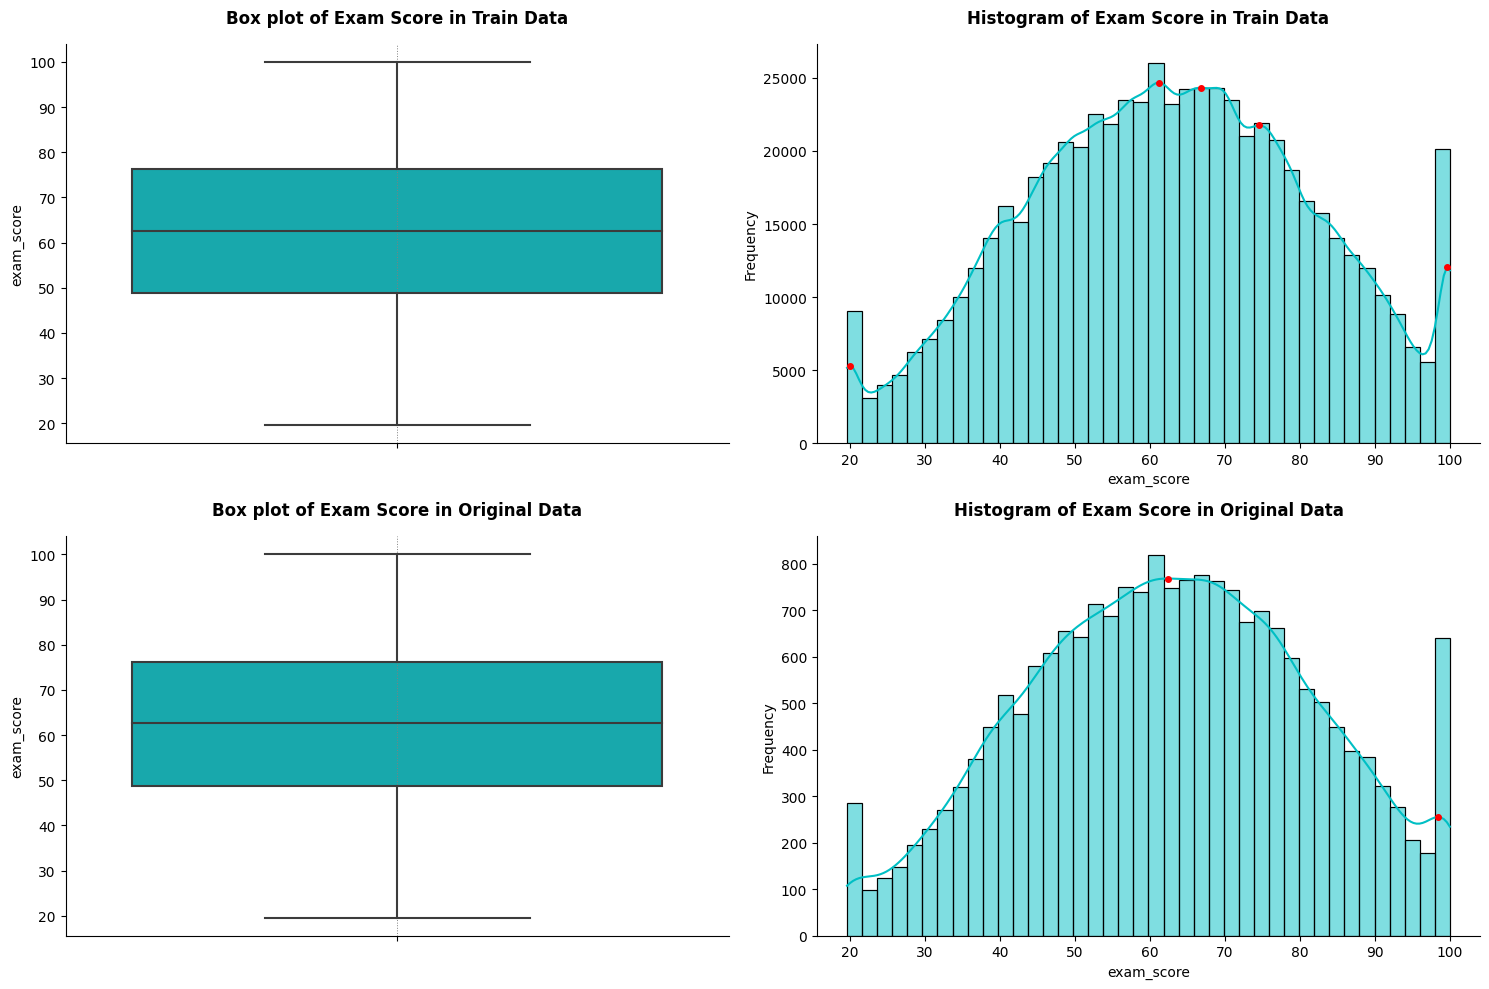

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharey=False, figsize=(15, 10))
datasets = [("Train Data", df_train), ("Original Data", df_original)]

for i, (title, df_) in enumerate(datasets):
    ax_box  = ax[i, 0]
    ax_hist = ax[i, 1]

    # If the target column is missing, skip and display a message on the plot
    if config.target_feature not in df_.columns:
        ax_box.axis('off'); ax_hist.axis('off')
        ax_box.text(0.5, 0.5, f"{title}: missing {config.target_feature}", ha="center", va="center")
        continue

    # Boxplot
    sns.boxplot(y=df_[config.target_feature], ax=ax_box, color="#00BFC4")
    ax_box.set_title(f"Box plot of Exam Score in {title}", fontsize=12, pad=15, weight="bold")
    ax_box.grid(axis="x", color="gray", linestyle=":", linewidth=0.7)
    sns.despine(ax=ax_box, top=True, right=True, left=False, bottom=False)

    # Histogram + KDE (draw KDE once with histplot)
    sns.histplot(df_[config.target_feature], ax=ax_hist, bins=40, kde=True, color="#00BFC4")
    ax_hist.set_title(f"Histogram of Exam Score in {title}", fontsize=12, pad=15, weight="bold")
    ax_hist.set_xlabel(config.target_feature); ax_hist.set_ylabel("Frequency")
    sns.despine(ax=ax_hist, top=True, right=True, left=False, bottom=False)

    # Get the KDE curve drawn by histplot (last line on the axis)
    kde_line = ax_hist.lines[-1]
    kde_x, kde_y = kde_line.get_data()

    # Find peaks on KDE (tune prominence/distance for smoother detection)
    peaks_idx, _ = find_peaks(kde_y, prominence=0.001, distance=10)
    ax_hist.plot(kde_x[peaks_idx], kde_y[peaks_idx], "ro", ms=4)

plt.tight_layout()
plt.show()

**Distribution Analysis of Exam Score**

* The distribution is **approximately normal**, centered around **60–65 points**, indicating a typical average performance level among students.
* The **interquartile range (IQR) is roughly 50–75 points**, where the majority of students’ scores are concentrated, reflecting moderate variability.
* Scores span a wide range from **~20 to 100**, covering low, average, and high achievers.
* **No clear outliers** are observed in the boxplots, suggesting well-controlled and realistic score values.
* The **histogram shapes of the Training and Original datasets are highly similar**:

  * Both peak around the **60–70** range
  * Left and right tails show comparable behavior
* This indicates that the **training dataset is highly representative of the original dataset**, with **no evident distribution shift**.

**Overall Insight:**

> *Exam scores follow an approximately normal distribution with moderate dispersion, no extreme outliers, and strong consistency between the training and original datasets—indicating reliable data quality and suitability for statistical modeling.*

## Numerical Feature Distributions

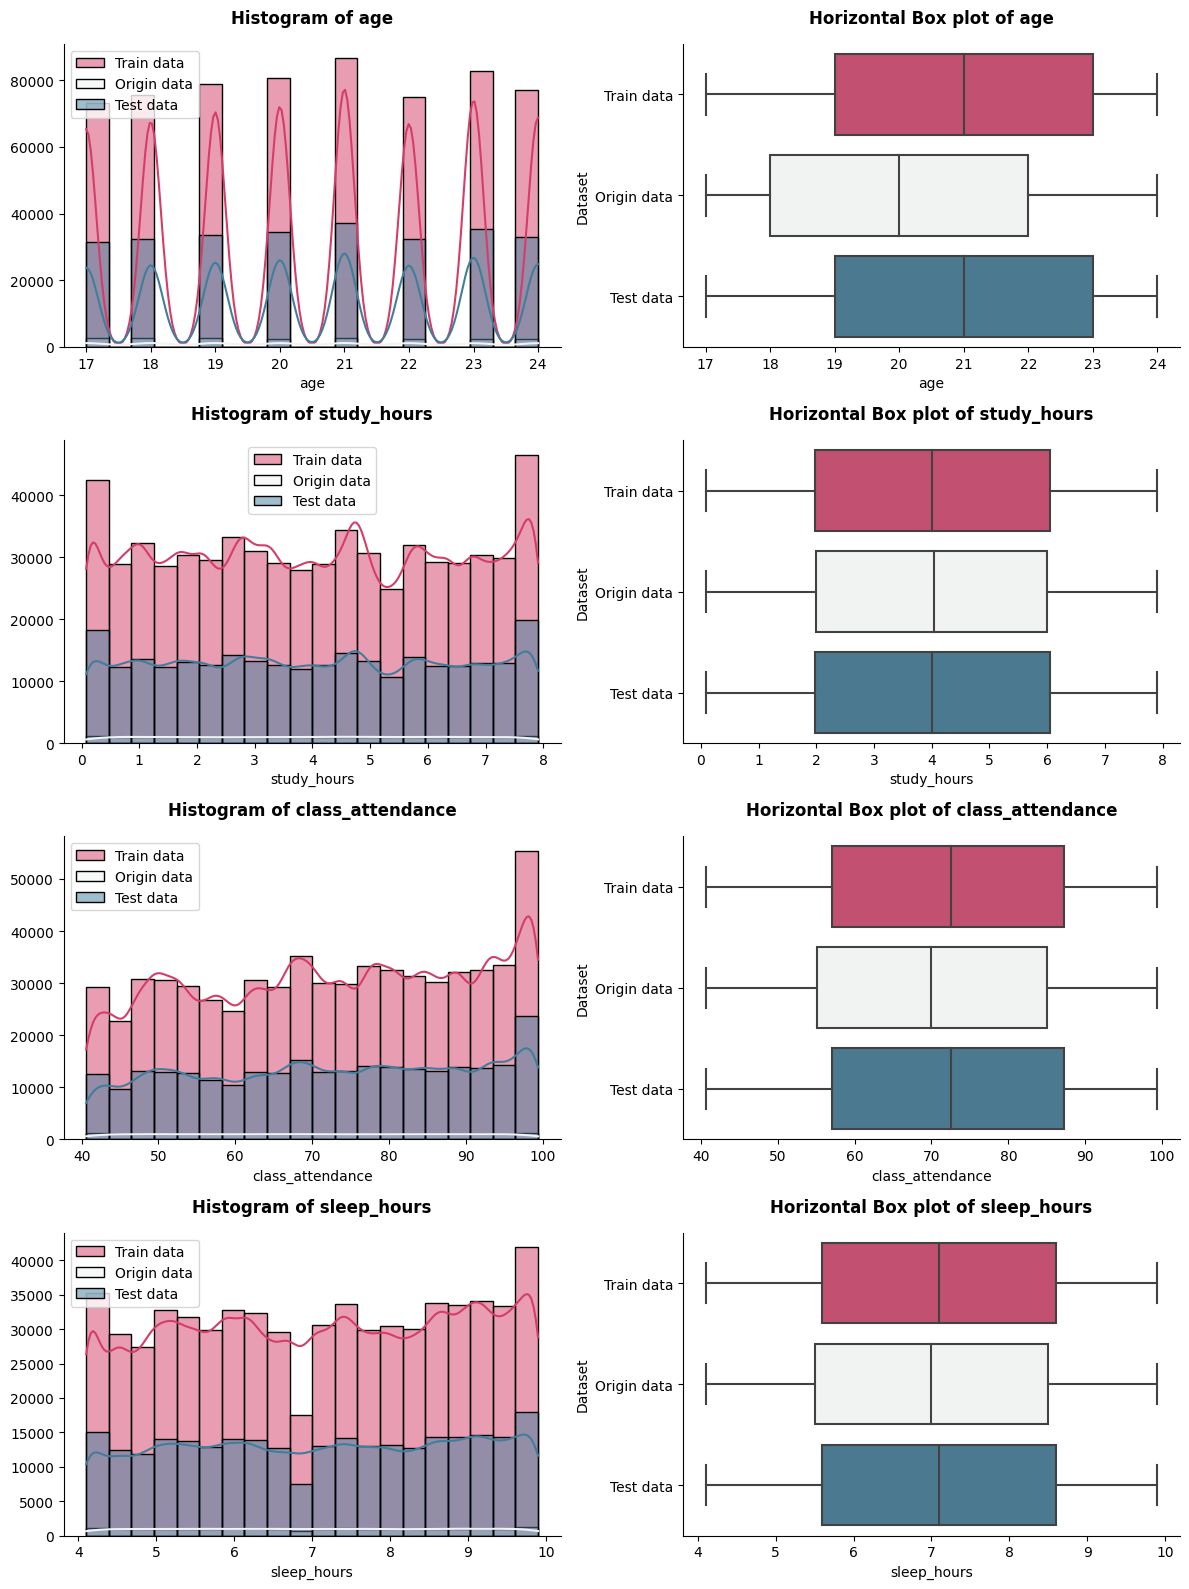

In [16]:
def plot_numerical_features(df_train, df_test, df_origin, num_features):
    colors = color(n_colors=3)
    n = len(num_features)

    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_origin[feature], color=colors[1], bins=20, kde=True, ax=ax[i, 0], label="Origin data")
        sns.histplot(data=df_test[feature], color=colors[2], bins=20, kde=True, ax=ax[i, 0], label="Test data")
        ax[i, 0].set_title(f"Histogram of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 0].legend()
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Origin data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        sns.boxplot(data=df_plot, x=feature, y="Dataset", palette=colors, orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", fontsize=12, pad=15, weight="bold")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_original, num_features=num_features)

In [17]:
def check_skewness(data, dataset_name, numerical_features = num_features, sort=True, logger=logger):
    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

        return skew_features

skew_feature_origin = check_skewness(df_original, "Original Data")
logger.info("-" * 70)
skew_feature_train = check_skewness(df_train, "Train Data")
logger.info("-" * 70)
skew_feature_test = check_skewness(df_test, "Test Data")
logger.info("-" * 70)
logger.info("Checking skewness successfully completed across datasets.")

2026-01-02 12:23:39 | INFO | Skewness analysis for Original Data
2026-01-02 12:23:39 | INFO | Total numerical features checked: 4
2026-01-02 12:23:39 | DEBUG | ----------------------------------------------------------------------
2026-01-02 12:23:39 | DEBUG | Feature                        | Skewness  | Remark
2026-01-02 12:23:39 | DEBUG | ----------------------------------------------------------------------
2026-01-02 12:23:39 | DEBUG | age                            |   +0.0148 | Approximately symmetric
2026-01-02 12:23:39 | DEBUG | study_hours                    |   -0.0103 | Approximately symmetric
2026-01-02 12:23:39 | DEBUG | class_attendance               |   -0.0013 | Approximately symmetric
2026-01-02 12:23:39 | DEBUG | sleep_hours                    |   -0.0008 | Approximately symmetric
2026-01-02 12:23:39 | DEBUG | ----------------------------------------------------------------------
2026-01-02 12:23:39 | INFO | No highly skewed features detected.
2026-01-02 12:23:39 | IN

**Insight**

* **Distributions are highly consistent across the Train, Test, and Original datasets**, with no visible distribution shifts → confirms that the synthetic Train/Test data are well-aligned with the Original data.
* **Histograms of `age`, `study_hours`, `class_attendance`, and `sleep_hours`** show **smooth, stable patterns** across datasets, without sharp peaks or heavy tails.
* **Boxplots indicate very similar medians and interquartile ranges (IQRs)** among all datasets, suggesting comparable central tendency and dispersion.
* **No extreme outliers are observed** in any of the numerical features, which supports reliable statistical analysis and model training.
* **Skewness values are all close to zero (|skew| < 0.1)** across Train, Test, and Original datasets:

  * All features are **approximately symmetric**
  * No highly or moderately skewed variables are detected
* As a result, **no transformation (log, Box–Cox, or Yeo–Johnson)** is required at this stage, and the features are **well-suited for parametric statistical tests and regression-based models**.

**Key takeaway:**

> *Numerical features exhibit near-symmetric distributions with strong consistency across Train, Test, and Original datasets, no meaningful skewness, and no outliers—indicating high data quality and minimal preprocessing requirements.*

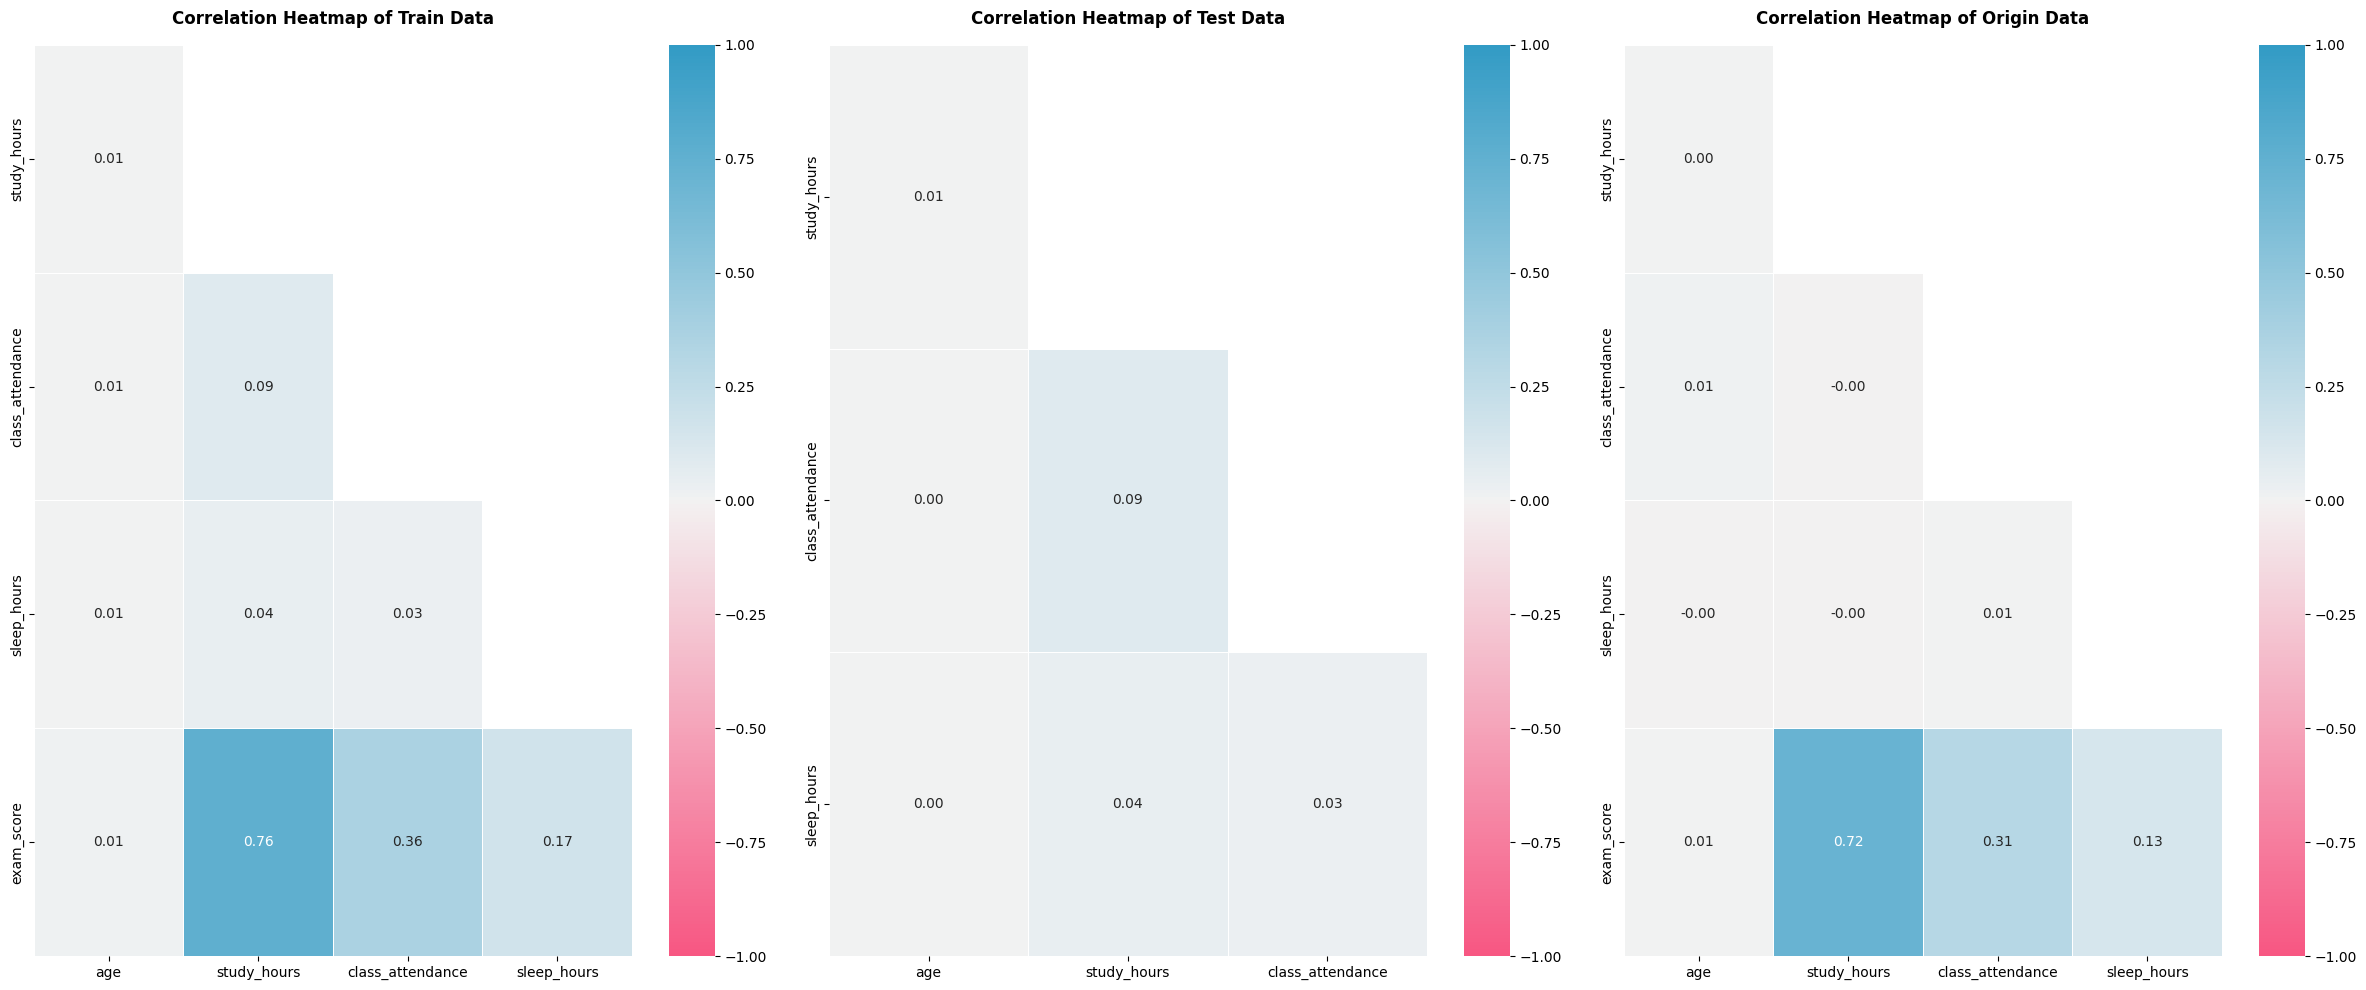

In [18]:
def plot_correlation(df_train, df_origin, df_test, origin_name="Origin Data", train_name="Train Data", test_name="Test Data"):
    corr_train = df_train.corr(numeric_only=True, method="pearson")
    corr_origin = df_origin.corr(numeric_only=True, method="pearson")
    corr_test = df_test.corr(numeric_only=True, method="pearson")

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_origin = np.triu(np.ones_like(corr_origin, dtype=bool))
    adjusted_mask_origin = mask_origin[1:, :-1]
    adjusted_cereal_corr_origin = corr_origin.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 3, figsize=(24, 10))

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=12, pad=15, weight="bold")

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=12, pad=15, weight="bold")

    sns.heatmap(data=adjusted_cereal_corr_origin, mask=adjusted_mask_origin,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[2])
    ax[2].set_title(f"Correlation Heatmap of {origin_name}", fontsize=12, pad=15, weight="bold")

    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train, df_origin=df_original, df_test=df_test)

**Insights from Correlation Analysis of Numerical Features**

* **Most numerical features exhibit weak correlations with each other**, indicating low linear dependency and **no multicollinearity issues**.
* **`study_hours` shows the strongest positive correlation with the target `exam_score`**:

  * Train data: **~+0.76**
  * Original data: **~+0.72**
    → This suggests that **study time is the most influential linear predictor** of exam performance.
* **`class_attendance` has a moderate positive correlation with `exam_score`**:

  * Ranging from **~+0.31 to +0.36**
    → Regular attendance contributes meaningfully to higher exam scores, though less strongly than study hours.
* **`sleep_hours` shows a weak positive correlation with `exam_score`**:

  * Around **~+0.13 to +0.17**
    → Adequate sleep appears beneficial, but its direct linear effect is relatively small.
* **`age` has virtually no correlation with `exam_score`** (≈ 0 across all datasets), indicating that age does not directly influence performance in this dataset.
* **Correlation patterns are highly consistent across Train, Test, and Original datasets**, confirming **no distribution or relationship shift** between synthetic and original data.

**Slide-ready takeaway:**

> *Study hours dominate the linear relationship with exam scores, attendance plays a supporting role, and other numerical features show weak effects—resulting in a clean dataset with low multicollinearity and strong consistency across datasets.*

## Categorical Feature Distributions

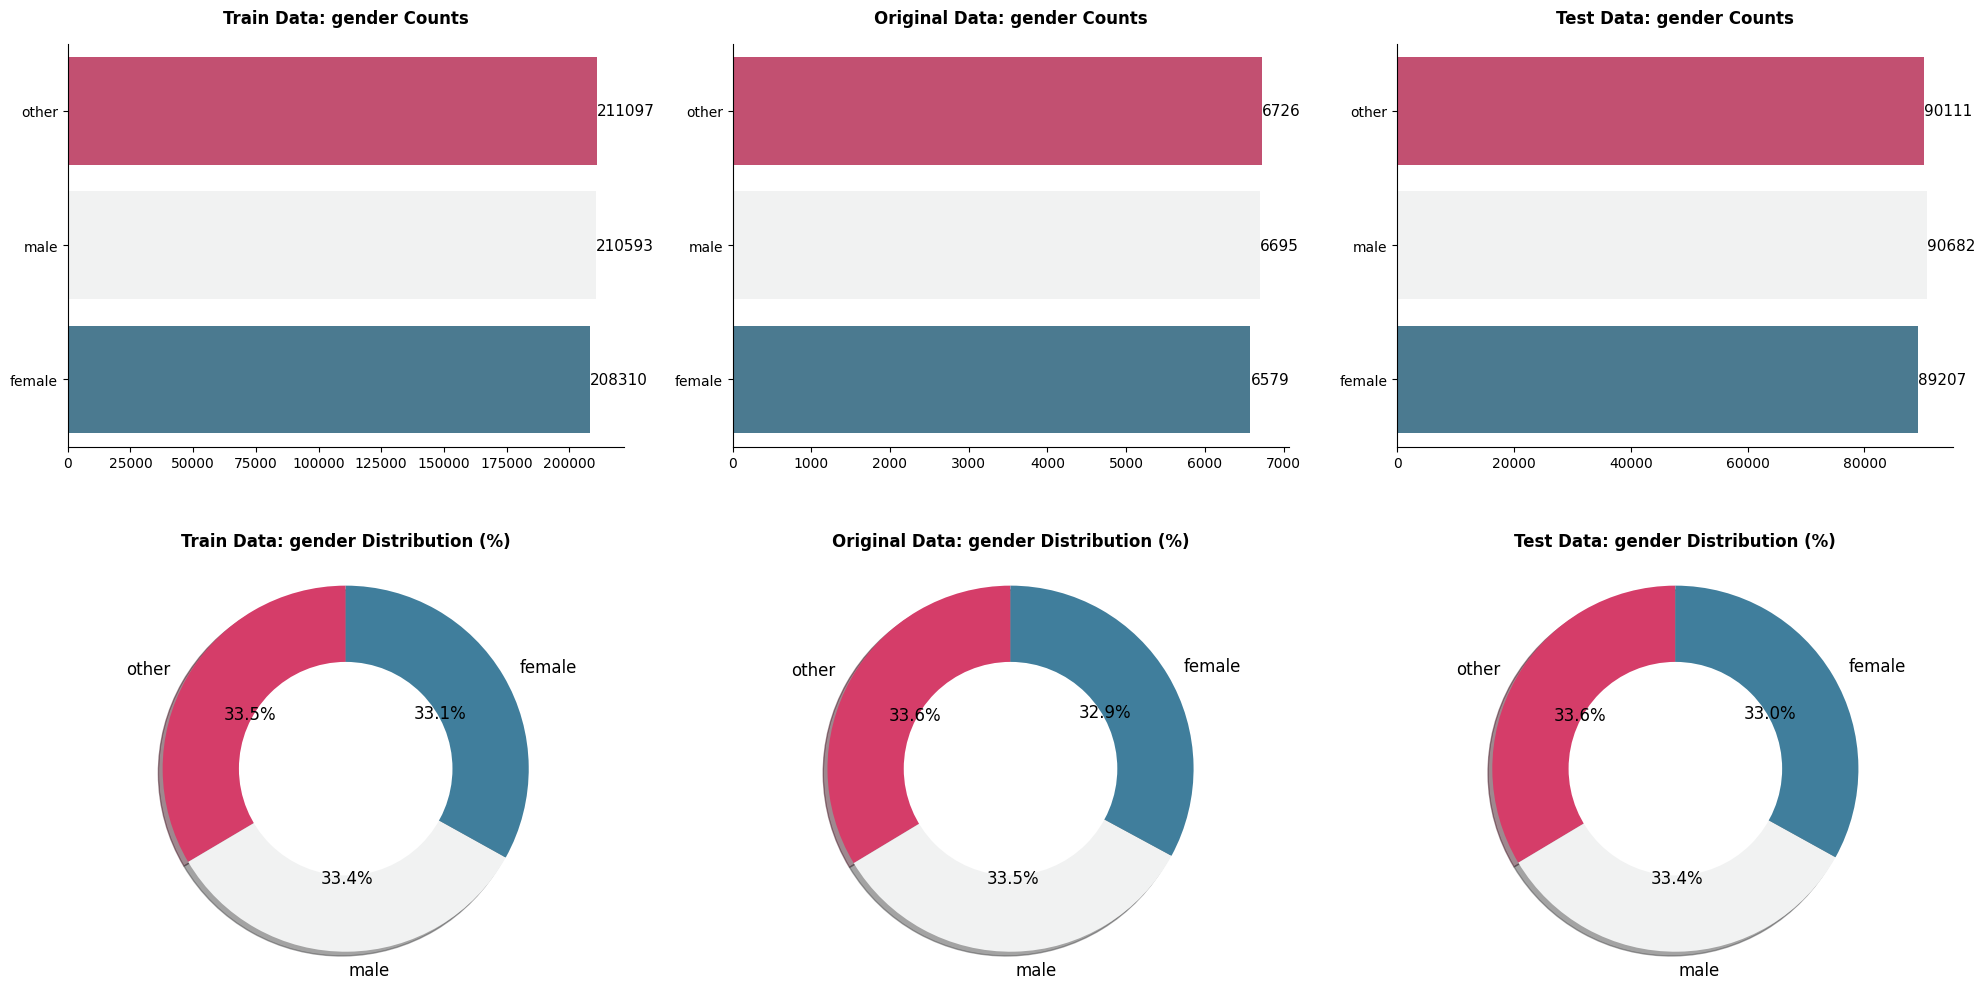

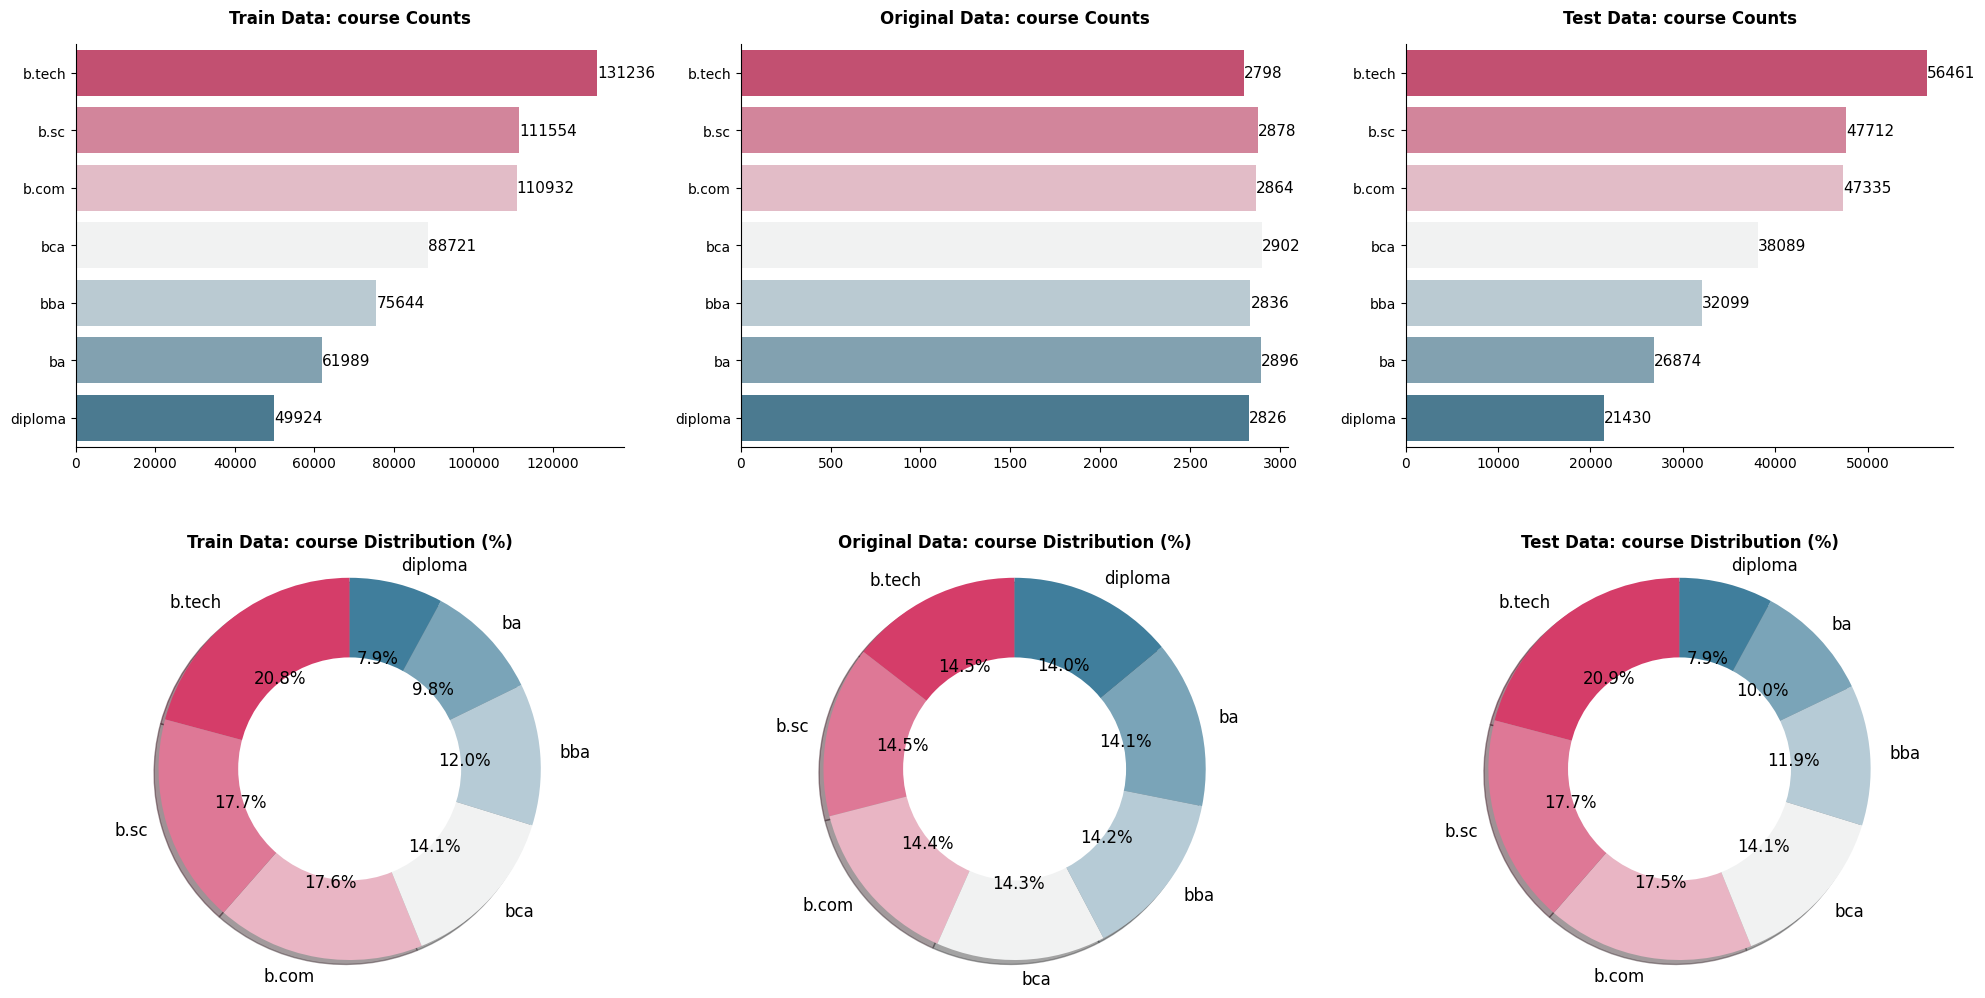

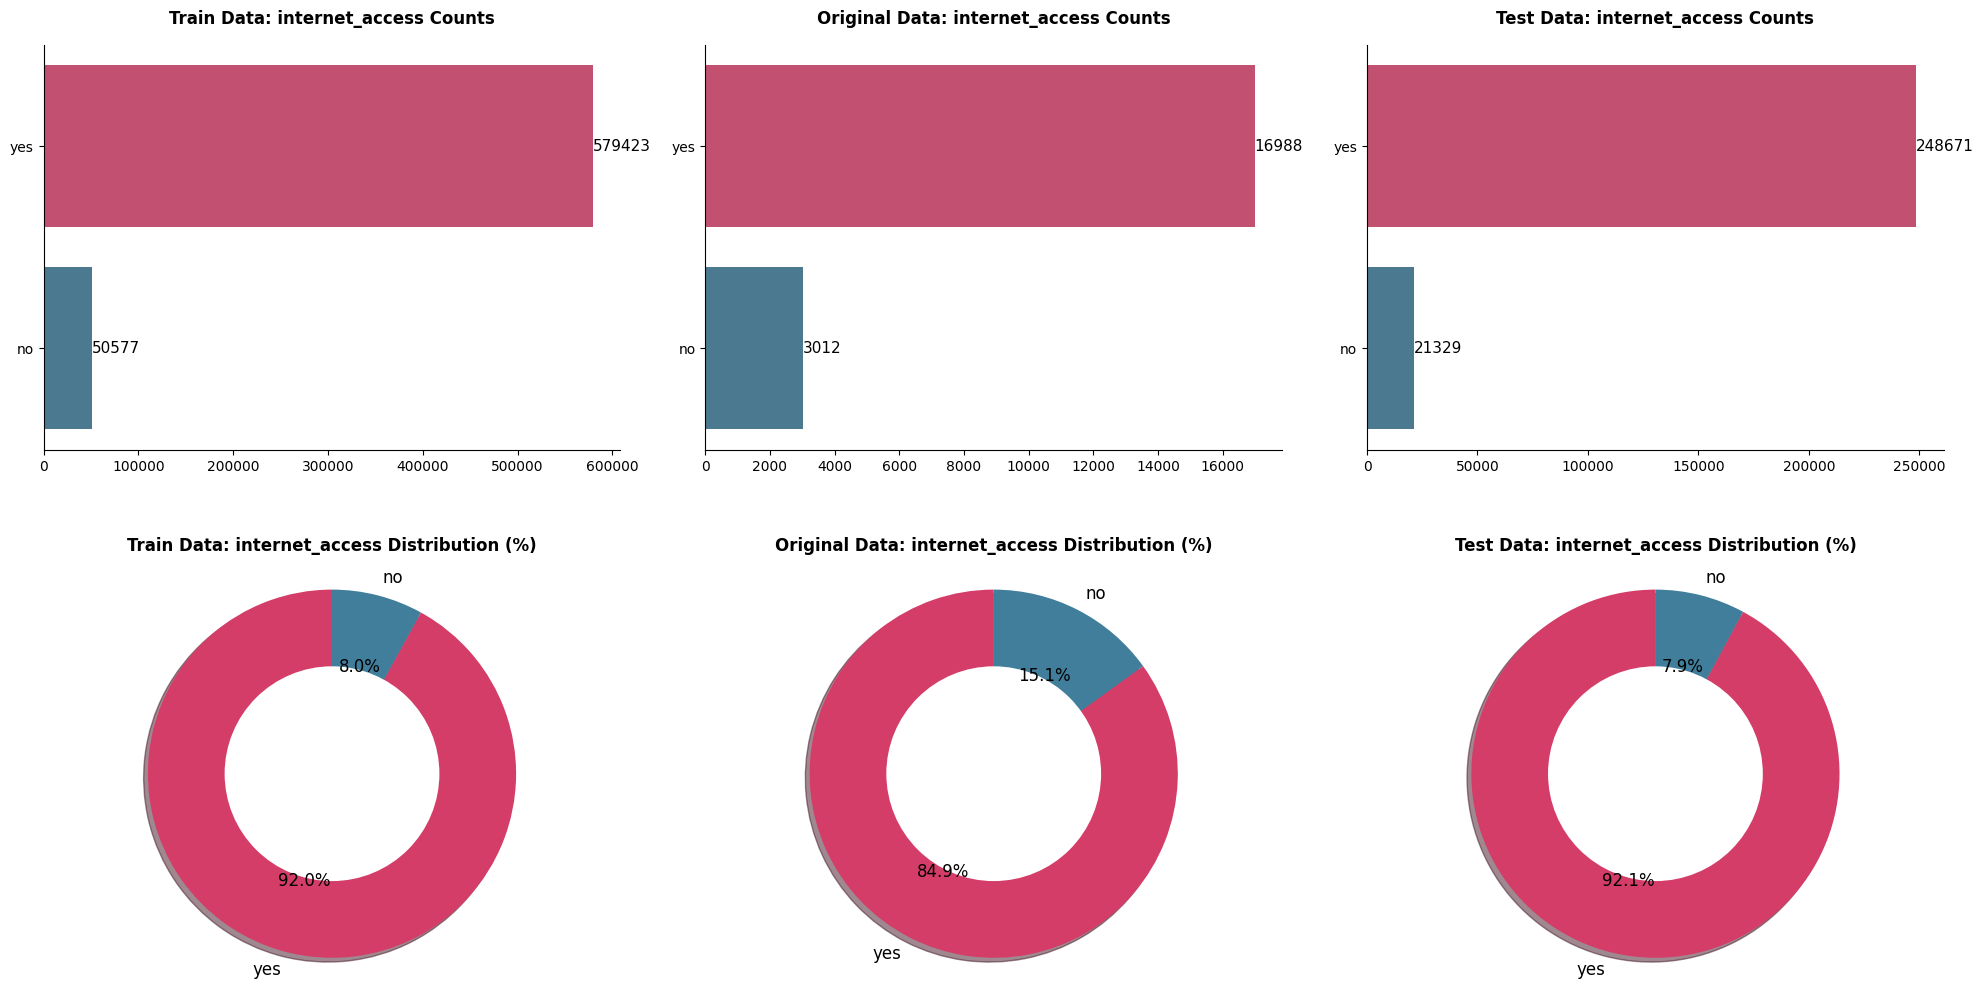

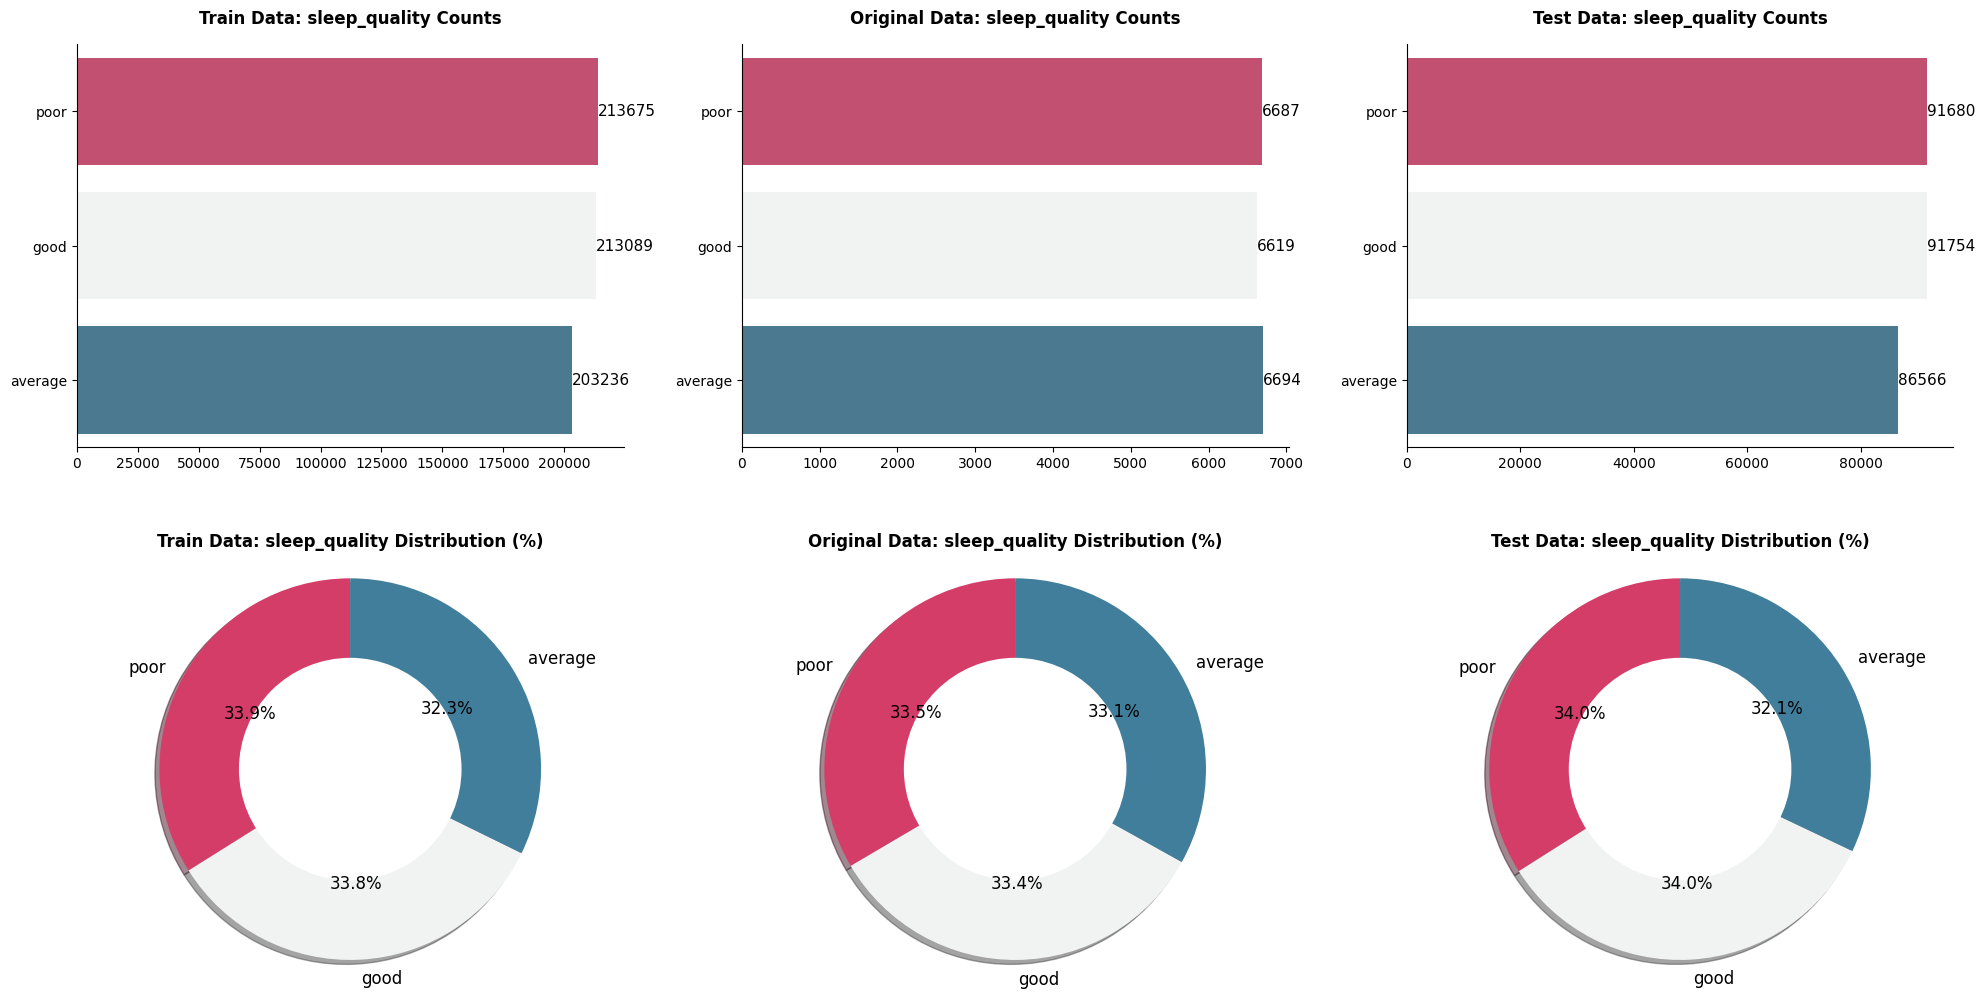

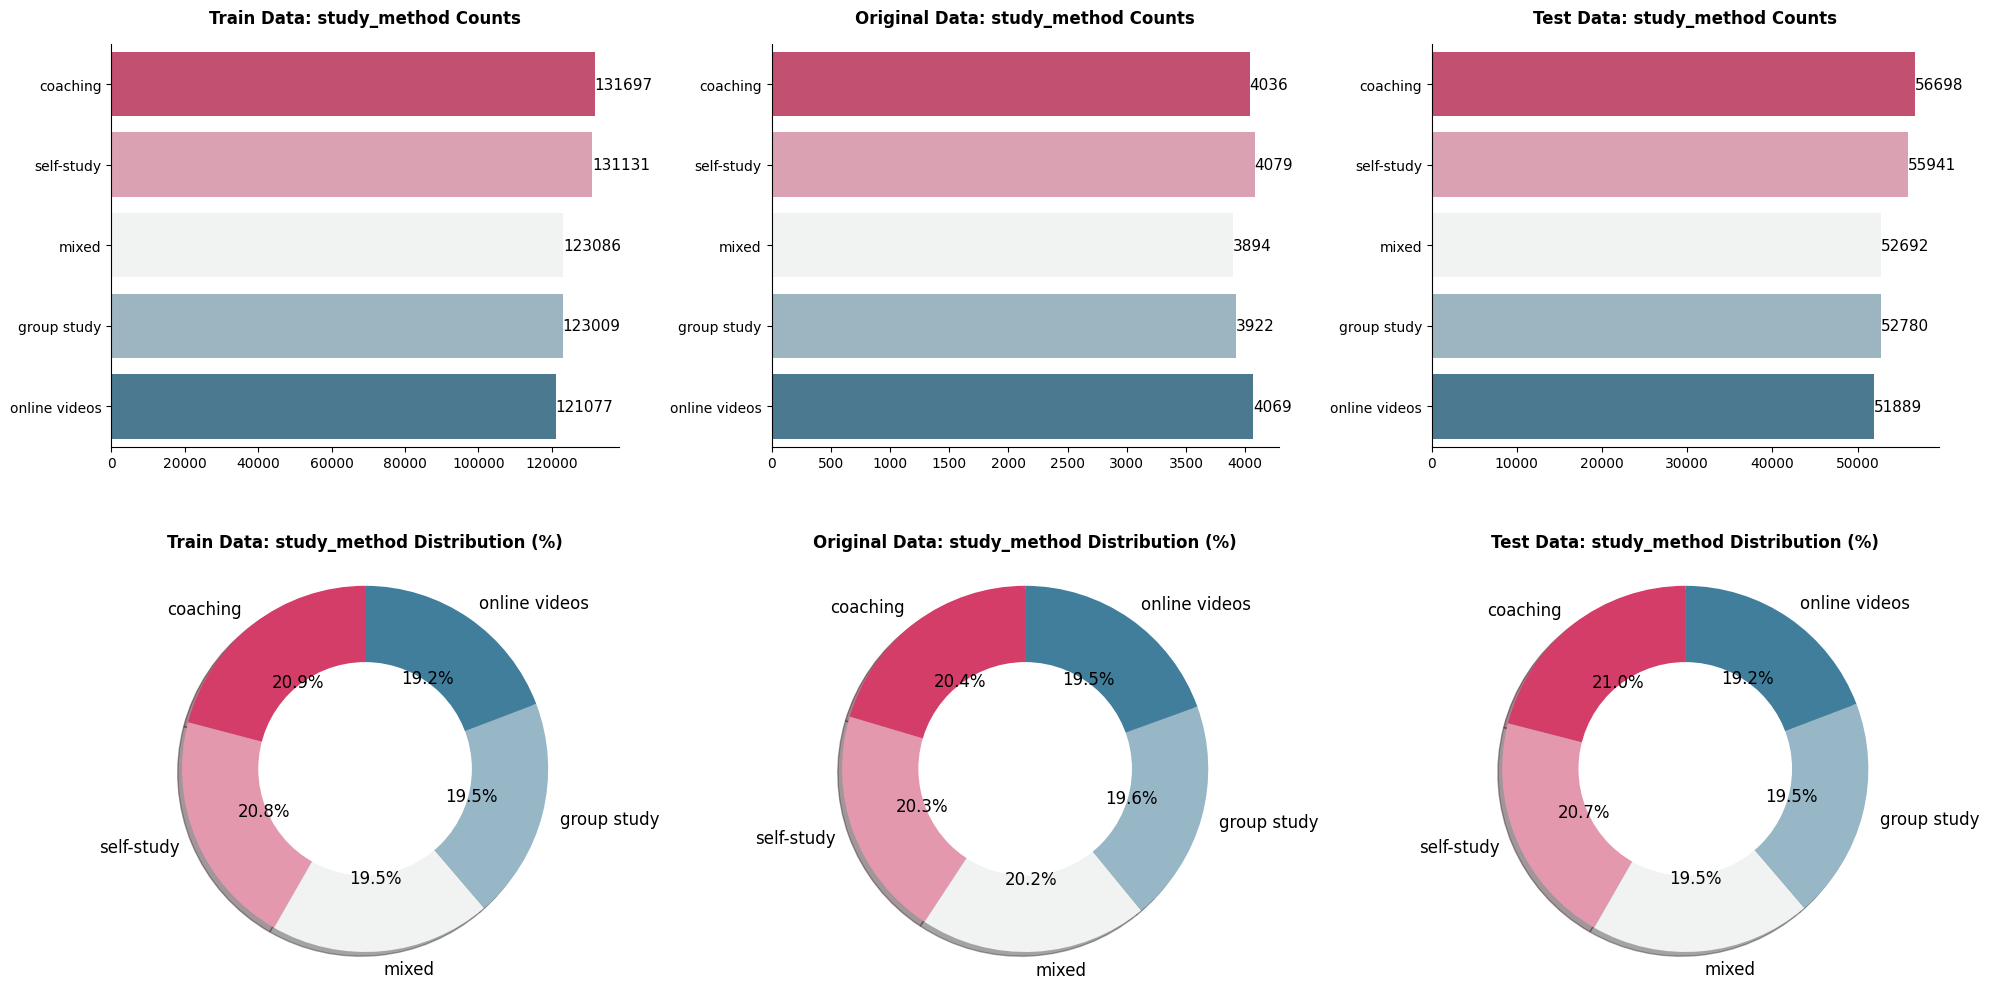

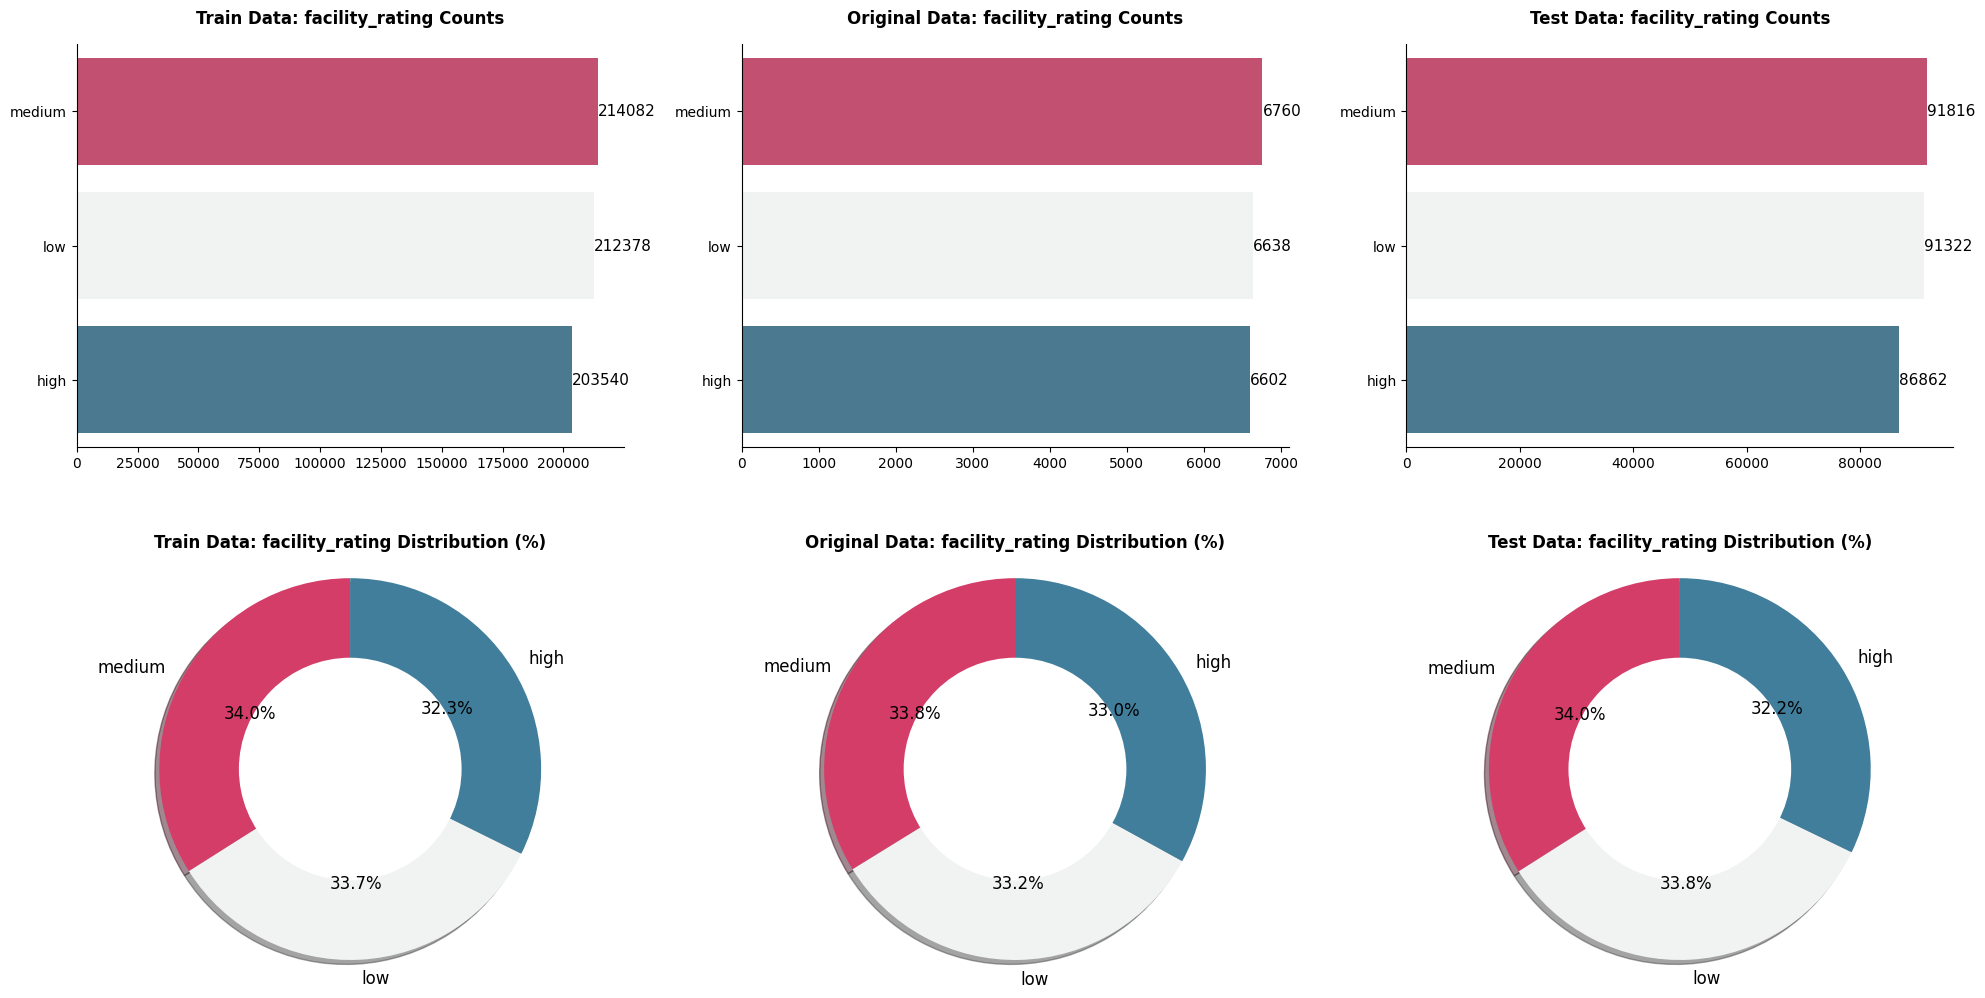

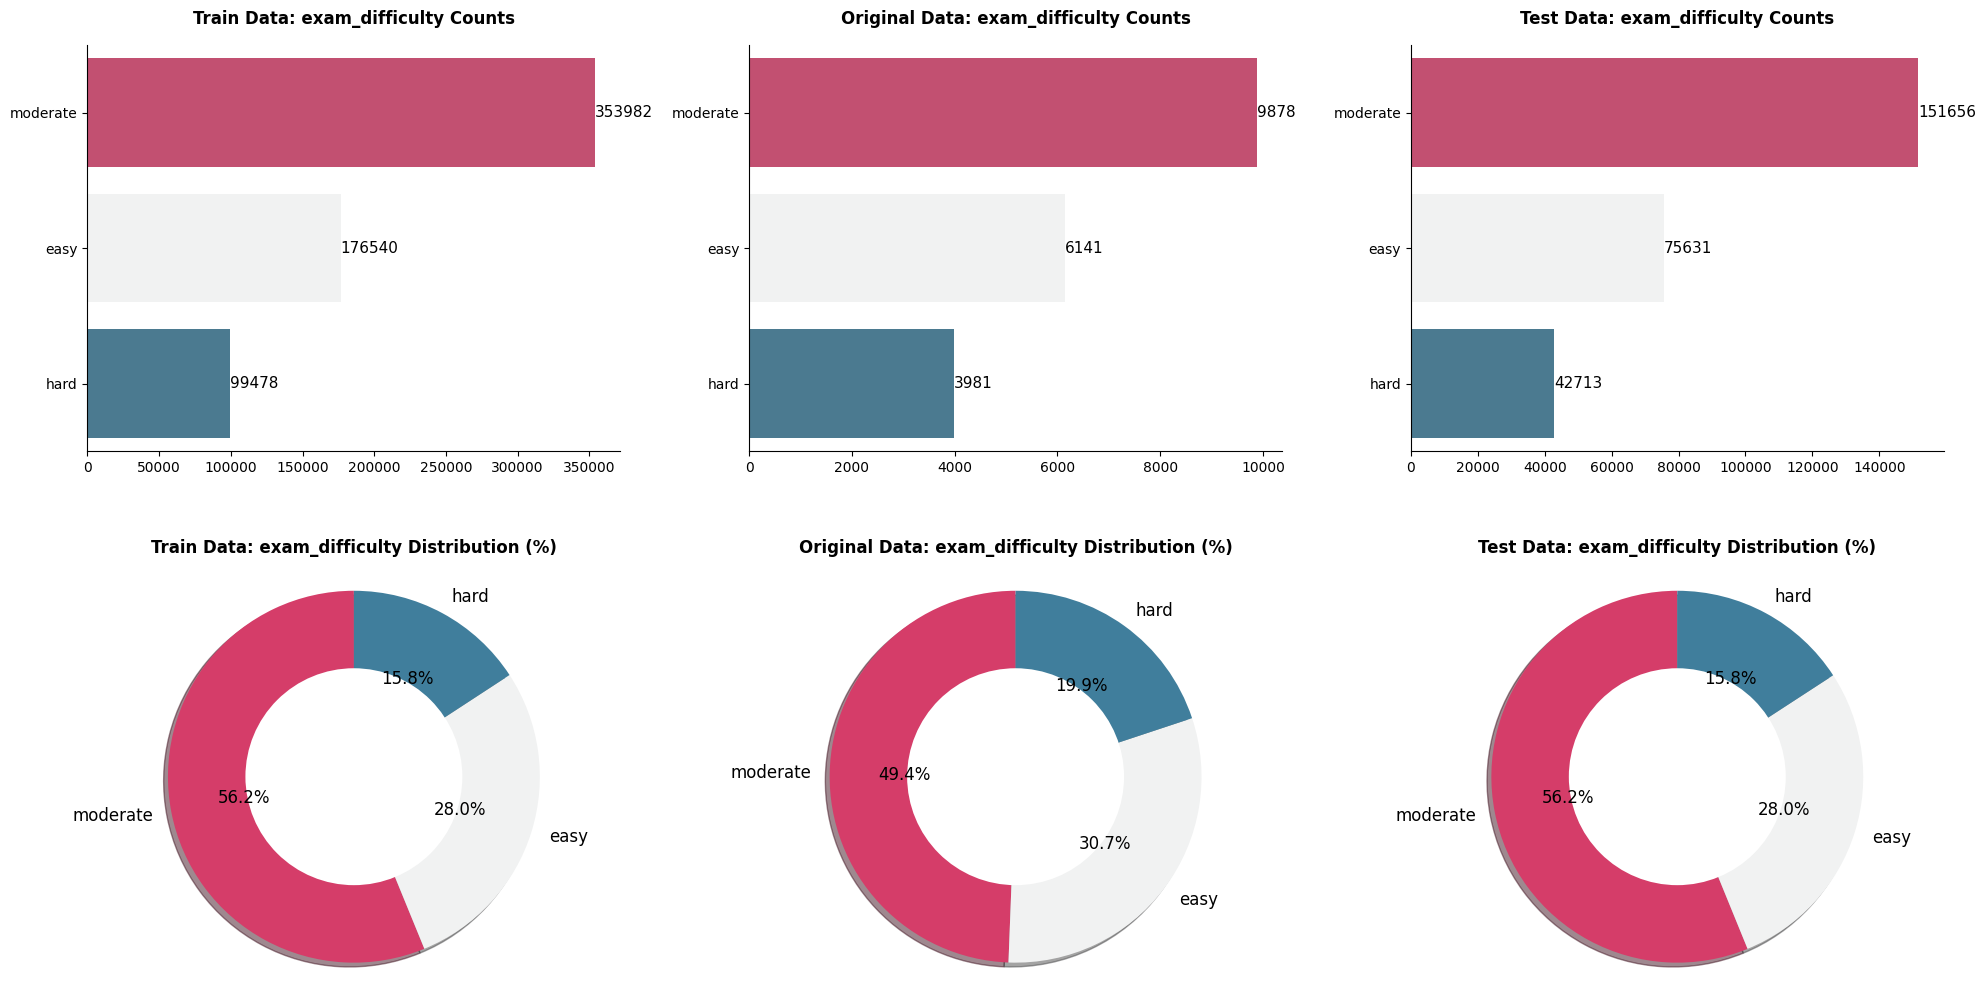

In [19]:
def plot_categorical_distribution_across_datasets(train_data, original_data, test_data, feature):
    dataset_names = ["Train", "Original", "Test"]
    datasets = [train_data, original_data, test_data]
    order = train_data[feature].value_counts().index.tolist()

    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    palette = sns.diverging_palette(0, 230, n=len(order))
    color_map = dict(zip(order, palette))

    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        sns.countplot(y=feature, data=data, ax=ax[0, i], palette=color_map, order=order)
        ax[0, i].set_title(f"{name} Data: {feature} Counts", fontsize=12, pad=15, weight="bold")
        ax[0, i].set_xlabel("")
        ax[0, i].set_ylabel("")
        
        for p in ax[0, i].patches:
            ax[0, i].annotate(f"{int(p.get_width())}", 
                               (p.get_width(), p.get_y() + p.get_height() / 2), 
                               ha="left", va="center", 
                               color="black", fontsize=11)
        ax[0, i].set_axisbelow(True)
        sns.despine(ax=ax[0, i])

    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        counts = data[feature].value_counts()
        wedges, texts, autotexts = ax[1, i].pie(
            counts, labels=order, autopct="%1.1f%%", startangle=90, colors=[color_map[c] for c in order],
            textprops={"fontsize": 12}, radius=1.2,  shadow=True)
        centre_circle = plt.Circle((0, 0), 0.70, fc="white")
        ax[1, i].add_artist(centre_circle)
        ax[1, i].set_title(f"{name} Data: {feature} Distribution (%)", fontsize=12, pad=15, weight="bold")
        ax[1, i].axis("equal")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_original, df_test, feature)

**Overall Consistency in Categorical Feature Distributions**

* The categorical variables across the **Train Test and Original datasets** show a **high degree of consistency**.
* There are **no noticeable signs of distributional shift** or **sampling bias** across datasets.

## Bivariate Analysis

In [20]:
df_train_combined = pd.concat([df_train, df_original], axis=0, ignore_index=True)

,gender,Count,Mean,Median,Std
0,other,217823,62.774393,62.600000,19.083944
1,female,214889,62.563799,62.500000,18.896342
2,male,217288,62.182399,62.500000,18.762858


2026-01-02 12:23:50 | INFO | Checking normality of feature 'exam_score' by groups of 'gender'...
2026-01-02 12:23:50 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:23:50 | DEBUG | Number of groups detected: 3
2026-01-02 12:23:50 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:23:50 | DEBUG | [gender=female] skew=-0.0255, kurtosis=-0.6039 → Approximately symmetric, Normal tails
2026-01-02 12:23:50 | DEBUG | [gender=male] skew=-0.0695, kurtosis=-0.5774 → Approximately symmetric, Normal tails
2026-01-02 12:23:50 | DEBUG | [gender=other] skew=-0.0516, kurtosis=-0.6752 → Approximately symmetric, Normal tails
2026-01-02 12:23:50 | INFO | Generating Q–Q plots for visual assessment...


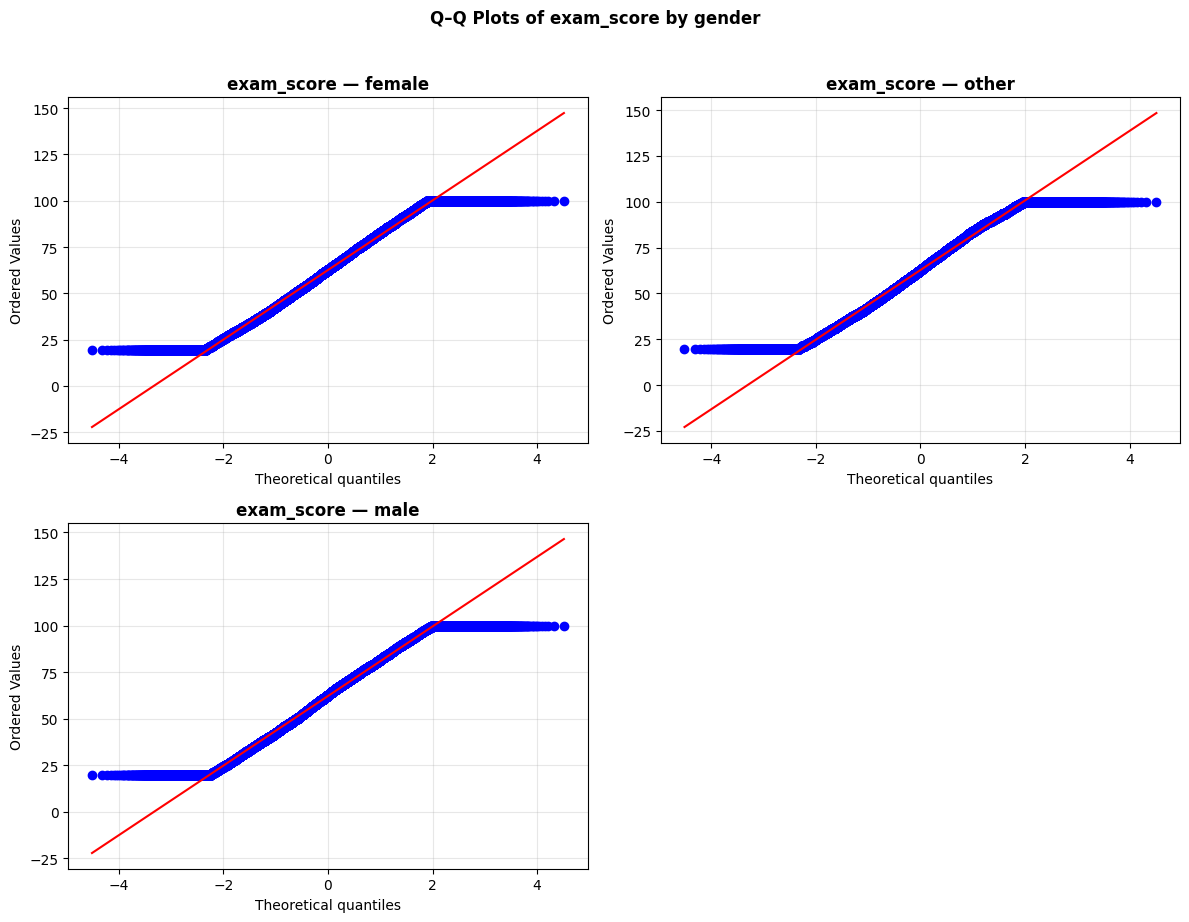

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,female,-0.0255,-0.6039,"Approximately symmetric, Normal tails"
1,exam_score,male,-0.0695,-0.5774,"Approximately symmetric, Normal tails"
2,exam_score,other,-0.0516,-0.6752,"Approximately symmetric, Normal tails"


2026-01-02 12:23:53 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:23:53 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:23:53 | DEBUG | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,65.6775
1,p-value,0.000000
2,Max/Min Variance Ratio,1.03


2026-01-02 12:23:53 | INFO | Interpretation:
2026-01-02 12:23:53 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:23:53 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:23:53 | INFO | Running Welch’s ANOVA Test: exam_score ~ gender
2026-01-02 12:23:53 | DEBUG | Number of groups detected: 3
2026-01-02 12:23:53 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:23:53 | INFO | Welch ANOVA F-statistic: 54.8582
2026-01-02 12:23:53 | INFO | p-value: 0.000000
2026-01-02 12:23:53 | DEBUG | Welch ANOVA table:
   Source  ddof1          ddof2          F         p-unc       np2
0  gender      2  433290.170971  54.858167  1.508054e-24  0.000168
2026-01-02 12:23:53 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:23:53 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:23:53 | DEBUG | Running Games–Howell 

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,female,male,62.5638,62.1824,0.3814,0.0573,6.6577,432032.0396,0.0000,0.0203
1,female,other,62.5638,62.7744,-0.2106,0.0577,-3.6474,432704.1331,0.0008,-0.0111
2,male,other,62.1824,62.7744,-0.5920,0.0574,-10.3175,435017.4410,0.0000,-0.0313


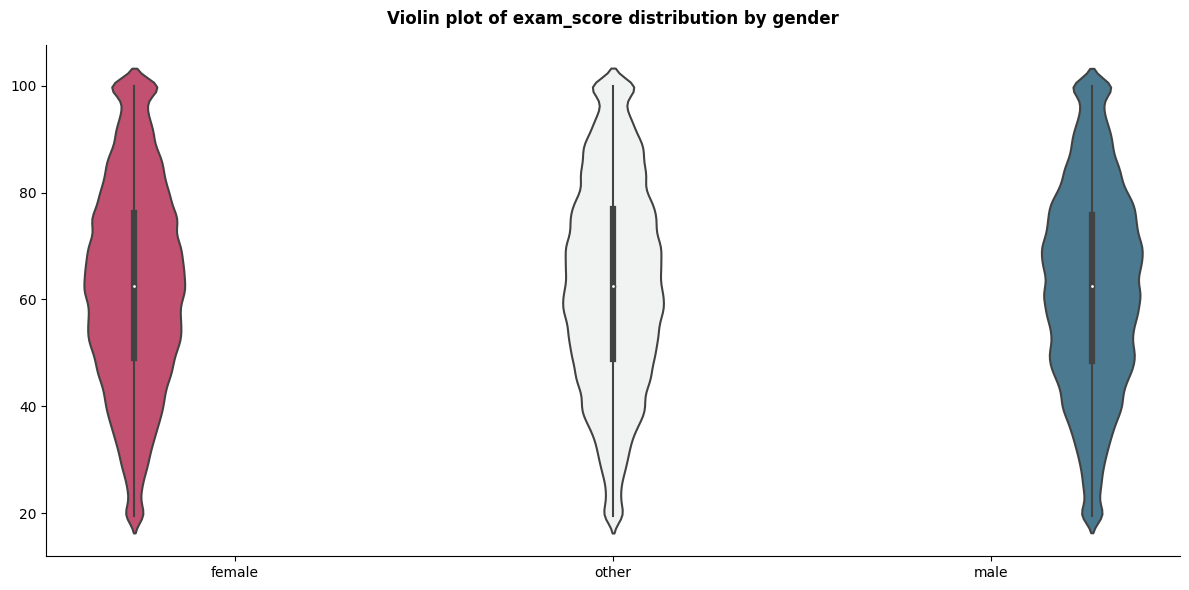

,course,Count,Mean,Median,Std
0,bba,78480,63.221056,63.500000,19.157103
1,bca,91623,62.584259,62.600000,18.919004
2,b.com,113796,62.532579,62.200000,18.410132
3,b.tech,134034,62.522501,62.400000,18.865253
4,diploma,52750,62.400404,61.900000,19.085984
5,b.sc,114432,62.306142,63.100000,19.289985
6,ba,64885,61.896986,62.300000,18.771322


2026-01-02 12:23:56 | INFO | Checking normality of feature 'exam_score' by groups of 'course'...
2026-01-02 12:23:56 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:23:56 | DEBUG | Number of groups detected: 7
2026-01-02 12:23:56 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:23:56 | DEBUG | [course=b.com] skew=0.0029, kurtosis=-0.6037 → Approximately symmetric, Normal tails
2026-01-02 12:23:56 | DEBUG | [course=b.sc] skew=-0.1070, kurtosis=-0.6241 → Approximately symmetric, Normal tails
2026-01-02 12:23:56 | DEBUG | [course=b.tech] skew=-0.0412, kurtosis=-0.6444 → Approximately symmetric, Normal tails
2026-01-02 12:23:56 | DEBUG | [course=ba] skew=-0.0291, kurtosis=-0.6096 → Approximately symmetric, Normal tails
2026-01-02 12:23:56 | DEBUG | [course=bba] skew=-0.1021, kurtosis=-0.6296 → Approximately symmetric, Normal tails
2026-01-02 12:23:56 | DEBUG | [course=bca] skew=-0.0415, kurtosis=-0.6222 → Approximately symmetric, Norma

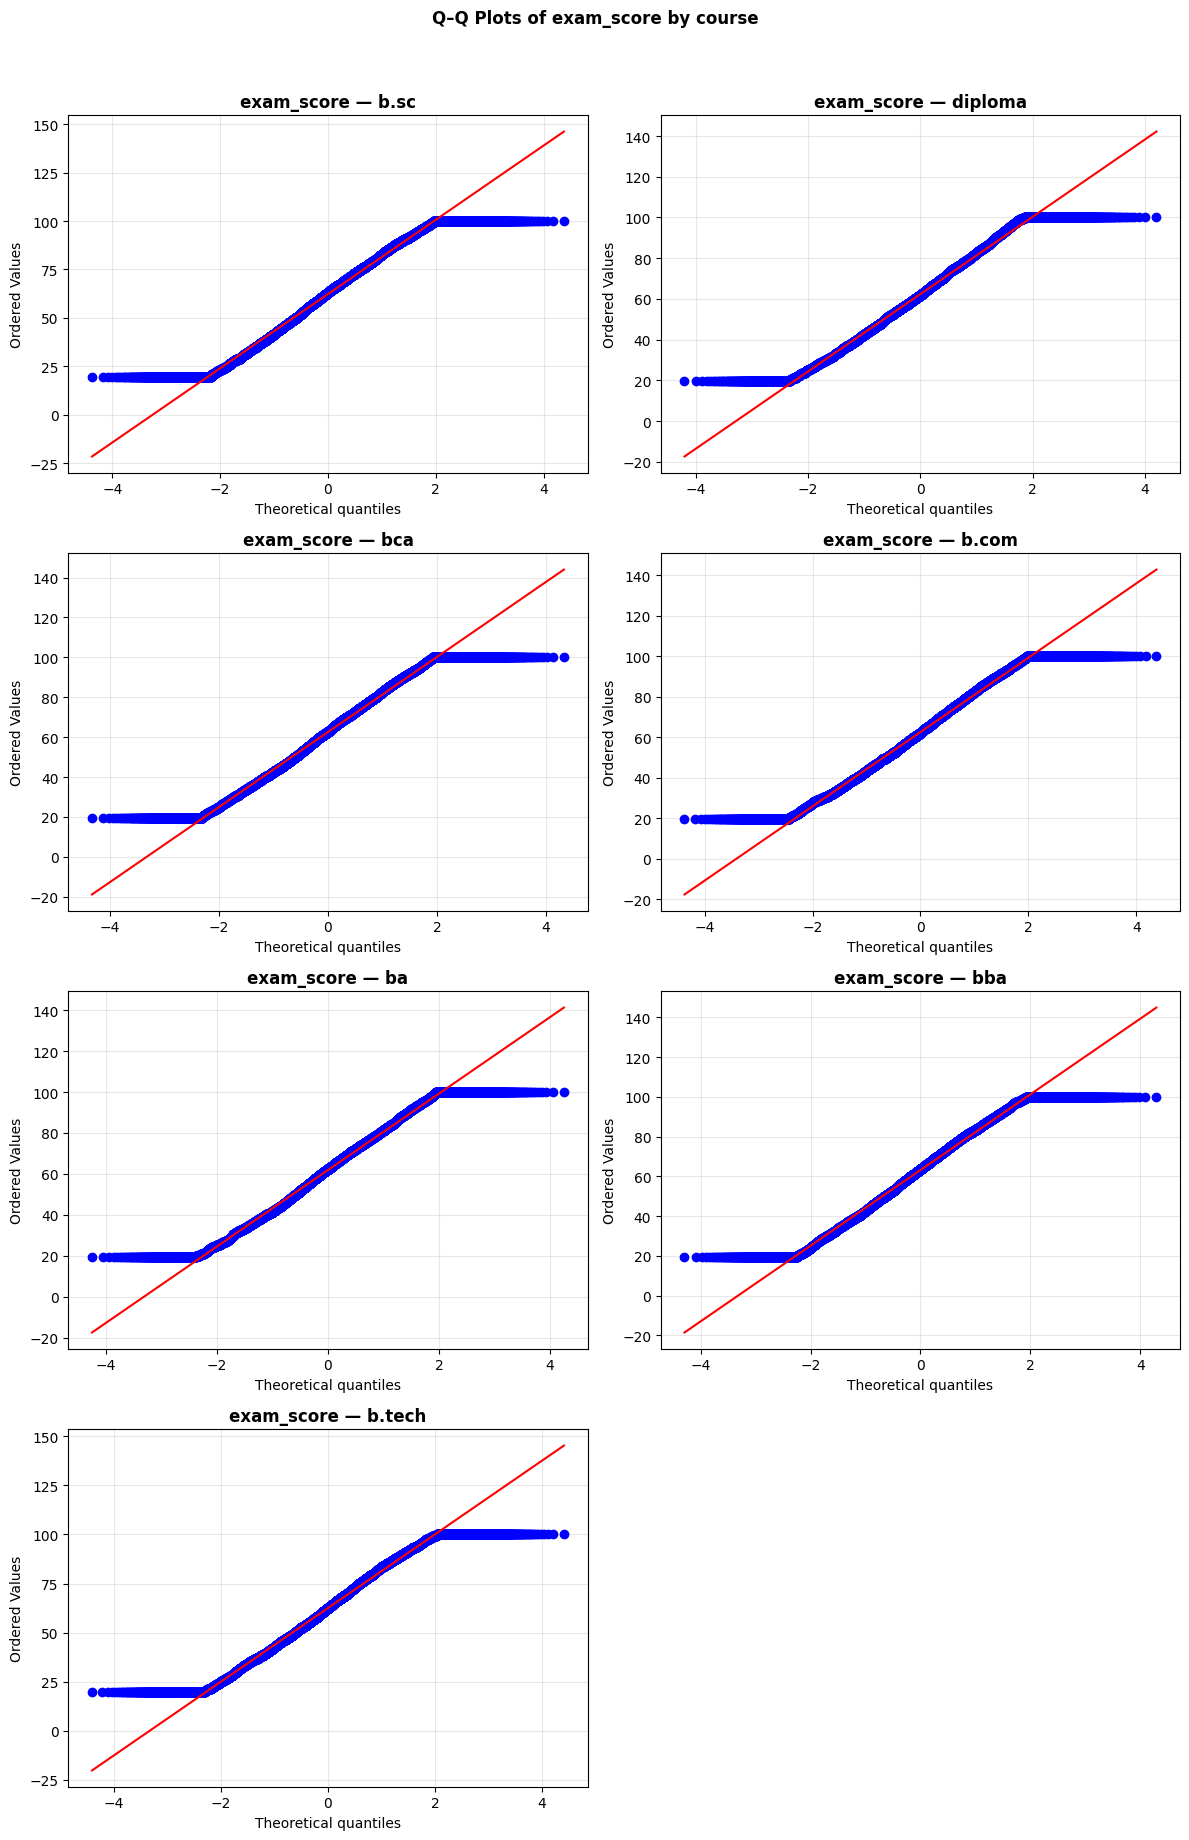

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,b.com,0.0029,-0.6037,"Approximately symmetric, Normal tails"
1,exam_score,b.sc,-0.1070,-0.6241,"Approximately symmetric, Normal tails"
2,exam_score,b.tech,-0.0412,-0.6444,"Approximately symmetric, Normal tails"
3,exam_score,ba,-0.0291,-0.6096,"Approximately symmetric, Normal tails"
4,exam_score,bba,-0.1021,-0.6296,"Approximately symmetric, Normal tails"
5,exam_score,bca,-0.0415,-0.6222,"Approximately symmetric, Normal tails"
6,exam_score,diploma,0.0110,-0.5836,"Approximately symmetric, Normal tails"


2026-01-02 12:23:59 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:00 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:00 | DEBUG | Number of groups detected: 7


,Metric,Value
0,Levene’s Statistic,49.5703
1,p-value,0.000000
2,Max/Min Variance Ratio,1.10


2026-01-02 12:24:00 | INFO | Interpretation:
2026-01-02 12:24:00 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:00 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:00 | INFO | Running Welch’s ANOVA Test: exam_score ~ course
2026-01-02 12:24:00 | DEBUG | Number of groups detected: 7
2026-01-02 12:24:00 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:24:01 | INFO | Welch ANOVA F-statistic: 32.2402
2026-01-02 12:24:01 | INFO | p-value: 0.000000
2026-01-02 12:24:01 | DEBUG | Welch ANOVA table:
   Source  ddof1          ddof2         F         p-unc       np2
0  course      6  253747.441331  32.24017  4.888256e-39  0.000301
2026-01-02 12:24:01 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:24:01 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:24:01 | DEBUG | Running Games–Howell po

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,b.com,b.sc,62.5326,62.3061,0.2264,0.0789,2.8688,227841.4374,0.0626,0.0120
1,b.com,b.tech,62.5326,62.5225,0.0101,0.0751,0.1343,243098.1458,1.0000,0.0005
2,b.com,ba,62.5326,61.8970,0.6356,0.0917,6.9312,132796.9013,0.0000,0.0343
3,b.com,bba,62.5326,63.2211,-0.6885,0.0875,-7.8691,164314.9600,0.0000,-0.0368
4,b.com,bca,62.5326,62.5843,-0.0517,0.0830,-0.6228,193859.2357,0.9961,-0.0028
5,b.com,diploma,62.5326,62.4004,0.1322,0.0994,1.3295,99484.3509,0.8383,0.0071
6,b.sc,b.tech,62.3061,62.5225,-0.2164,0.0769,-2.8151,240630.2448,0.0725,-0.0114
7,b.sc,ba,62.3061,61.8970,0.4092,0.0932,4.3911,137830.1101,0.0002,0.0214
8,b.sc,bba,62.3061,63.2211,-0.9149,0.0890,-10.2754,169395.4714,0.0000,-0.0476
9,b.sc,bca,62.3061,62.5843,-0.2781,0.0846,-3.2872,197865.4982,0.0175,-0.0145


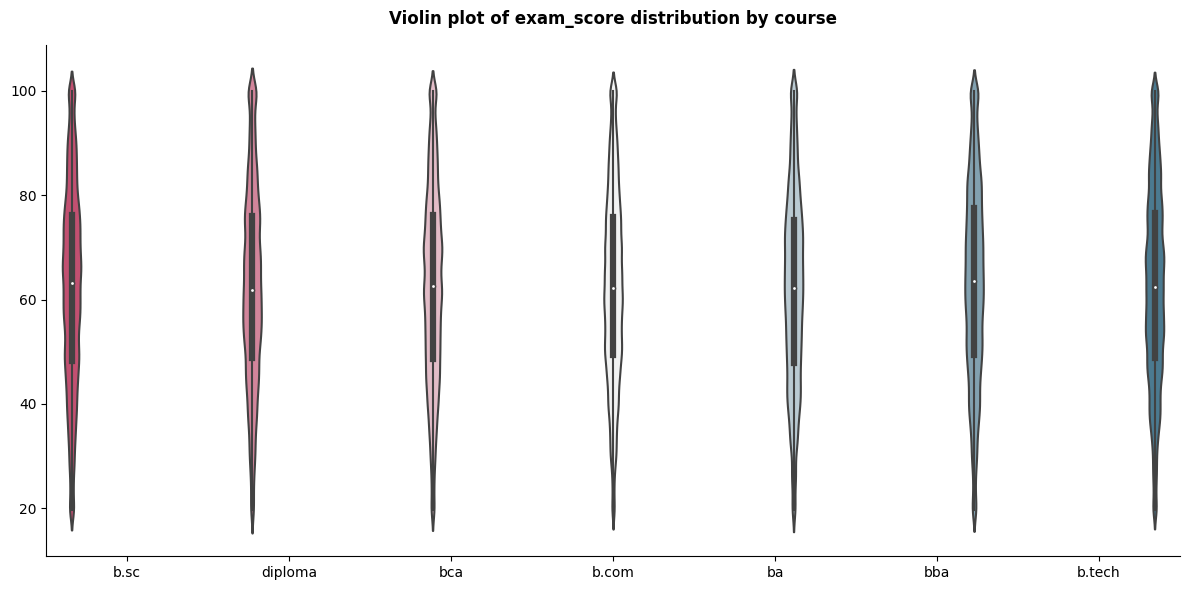

,internet_access,Count,Mean,Median,Std
0,yes,596411,62.507512,62.600000,18.884247
1,no,53589,62.499768,61.900000,19.273317


2026-01-02 12:24:03 | INFO | Checking normality of feature 'exam_score' by groups of 'internet_access'...
2026-01-02 12:24:03 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:24:04 | DEBUG | Number of groups detected: 2
2026-01-02 12:24:04 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:24:04 | DEBUG | [internet_access=no] skew=0.0234, kurtosis=-0.6966 → Approximately symmetric, Normal tails
2026-01-02 12:24:04 | DEBUG | [internet_access=yes] skew=-0.0551, kurtosis=-0.6117 → Approximately symmetric, Normal tails
2026-01-02 12:24:04 | INFO | Generating Q–Q plots for visual assessment...


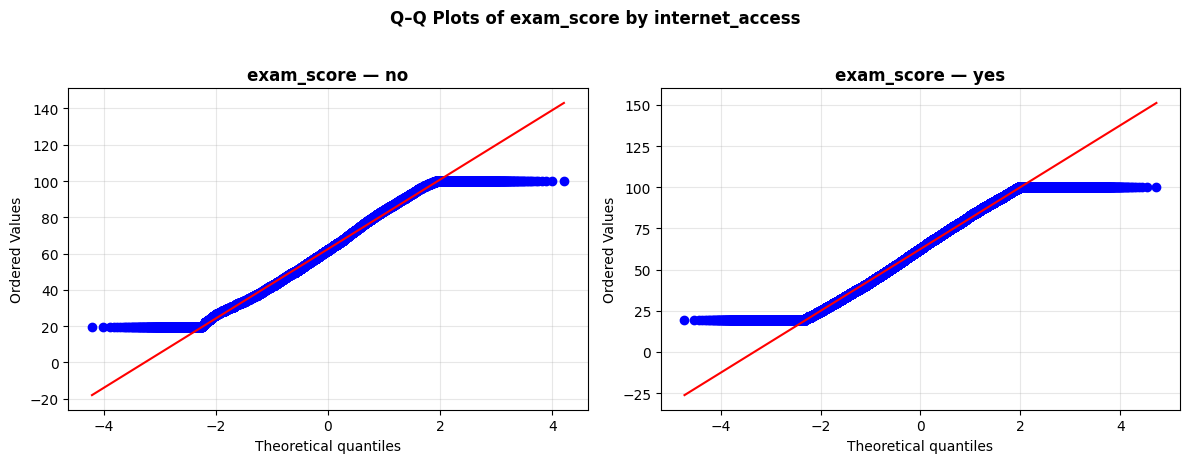

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,no,0.0234,-0.6966,"Approximately symmetric, Normal tails"
1,exam_score,yes,-0.0551,-0.6117,"Approximately symmetric, Normal tails"


2026-01-02 12:24:06 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:06 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:06 | DEBUG | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,63.3502
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04


2026-01-02 12:24:06 | INFO | Interpretation:
2026-01-02 12:24:06 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:06 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:06 | INFO | Running Independent Two-Sample T-Test: 'exam_score' ~ 'internet_access'
2026-01-02 12:24:06 | DEBUG | Number of groups detected: 2
2026-01-02 12:24:06 | DEBUG | Test Type: Welch’s T-Test (unequal variances)
2026-01-02 12:24:06 | INFO | 
[i] Comparing groups: 'no' vs 'yes'
2026-01-02 12:24:06 | INFO | [i] p-value: 0.928886
2026-01-02 12:24:06 | INFO | [i] Cohen's d: -0.000
2026-01-02 12:24:06 | DEBUG | t-statistic: -0.089
2026-01-02 12:24:06 | DEBUG | Group means → no: 62.500, yes: 62.508
2026-01-02 12:24:06 | WARNING | Result: p-value > 0.05 → Fail to reject H0
2026-01-02 12:24:06 | WARNING | Conclusion: No statistically significant difference detected.


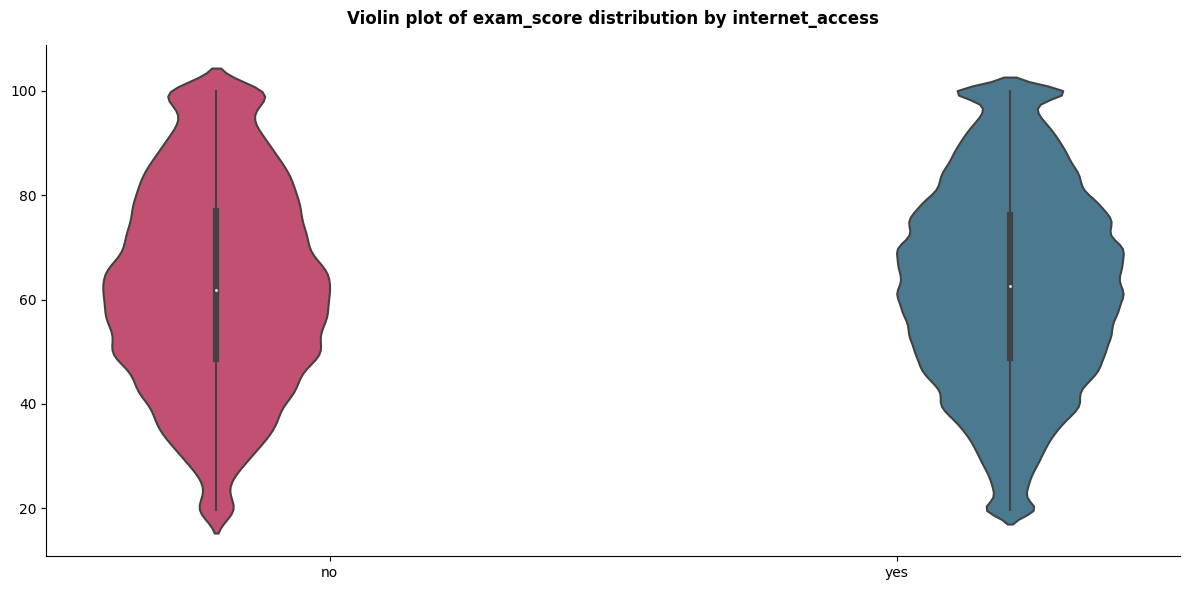

,sleep_quality,Count,Mean,Median,Std
0,good,219708,67.862402,68.200000,18.124274
1,average,209930,62.657807,62.600000,18.601161
2,poor,220362,57.023452,57.200000,18.430721


2026-01-02 12:24:08 | INFO | Checking normality of feature 'exam_score' by groups of 'sleep_quality'...
2026-01-02 12:24:08 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:24:09 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:09 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:24:09 | DEBUG | [sleep_quality=average] skew=-0.0389, kurtosis=-0.6402 → Approximately symmetric, Normal tails
2026-01-02 12:24:09 | DEBUG | [sleep_quality=good] skew=-0.1339, kurtosis=-0.6408 → Approximately symmetric, Normal tails
2026-01-02 12:24:09 | DEBUG | [sleep_quality=poor] skew=0.0411, kurtosis=-0.5753 → Approximately symmetric, Normal tails
2026-01-02 12:24:09 | INFO | Generating Q–Q plots for visual assessment...


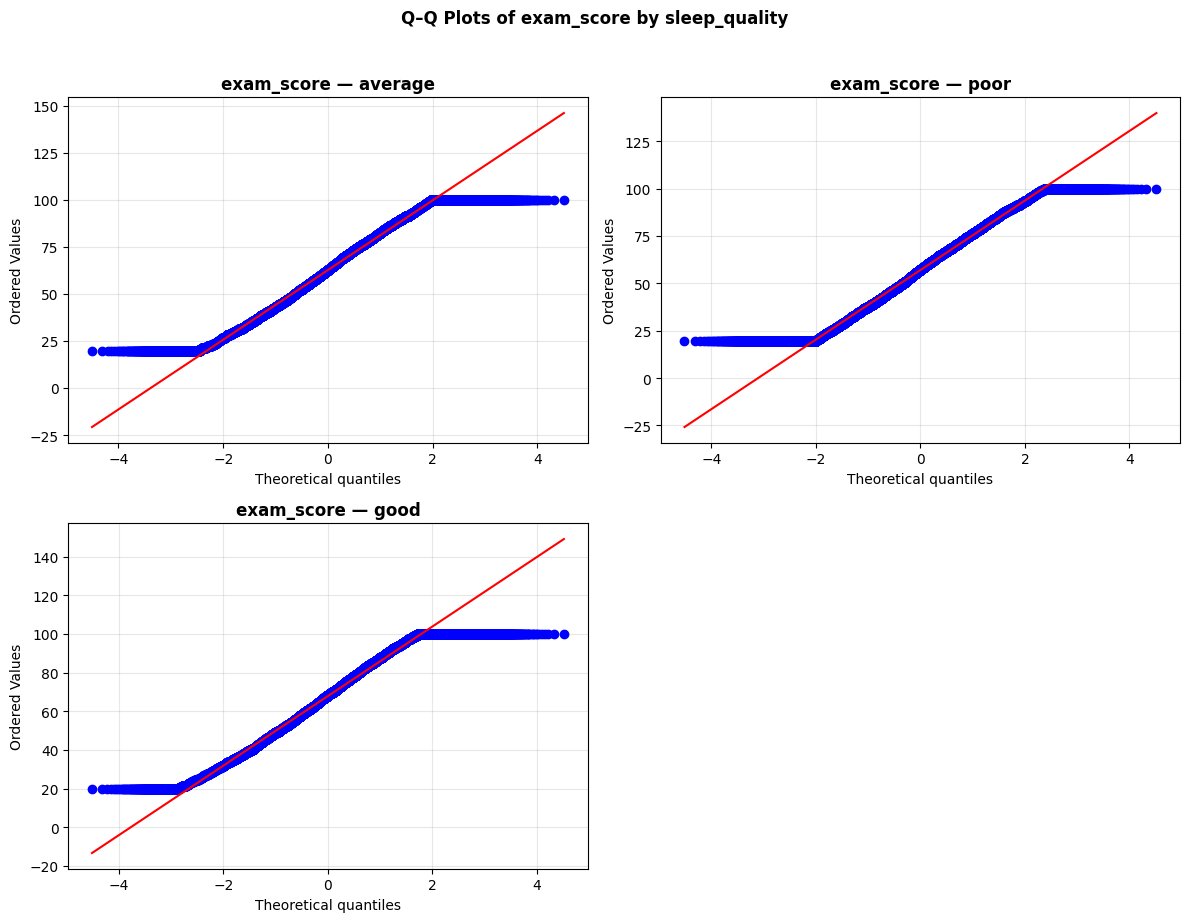

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,average,-0.0389,-0.6402,"Approximately symmetric, Normal tails"
1,exam_score,good,-0.1339,-0.6408,"Approximately symmetric, Normal tails"
2,exam_score,poor,0.0411,-0.5753,"Approximately symmetric, Normal tails"


2026-01-02 12:24:11 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:11 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:11 | DEBUG | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,84.5153
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05


2026-01-02 12:24:11 | INFO | Interpretation:
2026-01-02 12:24:11 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:11 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:12 | INFO | Running Welch’s ANOVA Test: exam_score ~ sleep_quality
2026-01-02 12:24:12 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:12 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:24:12 | INFO | Welch ANOVA F-statistic: 19347.8543
2026-01-02 12:24:12 | INFO | p-value: 0.000000
2026-01-02 12:24:12 | DEBUG | Welch ANOVA table:
          Source  ddof1          ddof2             F  p-unc     np2
0  sleep_quality      2  432576.721944  19347.854342    0.0  0.0556
2026-01-02 12:24:12 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:24:12 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:24:12 | DEBUG | Running G

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,average,good,62.6578,67.8624,-5.2046,0.0561,-92.8312,427452.3914,0.0000,-0.2835
1,average,poor,62.6578,57.0235,5.6344,0.0565,99.7630,428862.0696,0.0000,0.3043
2,good,poor,67.8624,57.0235,10.8390,0.0551,196.6940,439984.2912,0.0000,0.5930


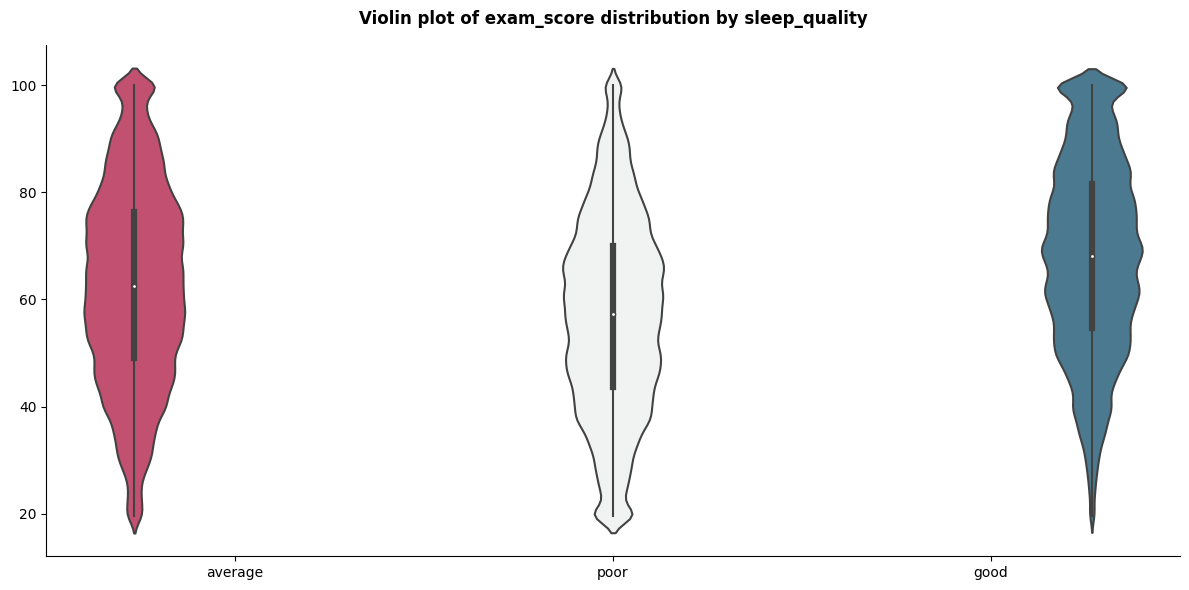

,study_method,Count,Mean,Median,Std
0,coaching,135733,69.245384,69.300000,18.445520
1,mixed,126980,65.075397,65.600000,18.224776
2,group study,126931,60.545299,60.800000,18.229511
3,online videos,125146,59.741395,59.600000,18.730065
4,self-study,135210,57.731221,57.300000,18.569673


2026-01-02 12:24:15 | INFO | Checking normality of feature 'exam_score' by groups of 'study_method'...
2026-01-02 12:24:15 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:24:15 | DEBUG | Number of groups detected: 5
2026-01-02 12:24:15 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:24:15 | DEBUG | [study_method=coaching] skew=-0.1390, kurtosis=-0.6966 → Approximately symmetric, Normal tails
2026-01-02 12:24:15 | DEBUG | [study_method=group study] skew=-0.0040, kurtosis=-0.5786 → Approximately symmetric, Normal tails
2026-01-02 12:24:15 | DEBUG | [study_method=mixed] skew=-0.1816, kurtosis=-0.5617 → Approximately symmetric, Normal tails
2026-01-02 12:24:15 | DEBUG | [study_method=online videos] skew=-0.0207, kurtosis=-0.5953 → Approximately symmetric, Normal tails
2026-01-02 12:24:15 | DEBUG | [study_method=self-study] skew=0.0717, kurtosis=-0.6076 → Approximately symmetric, Normal tails
2026-01-02 12:24:15 | INFO | Generating Q–Q

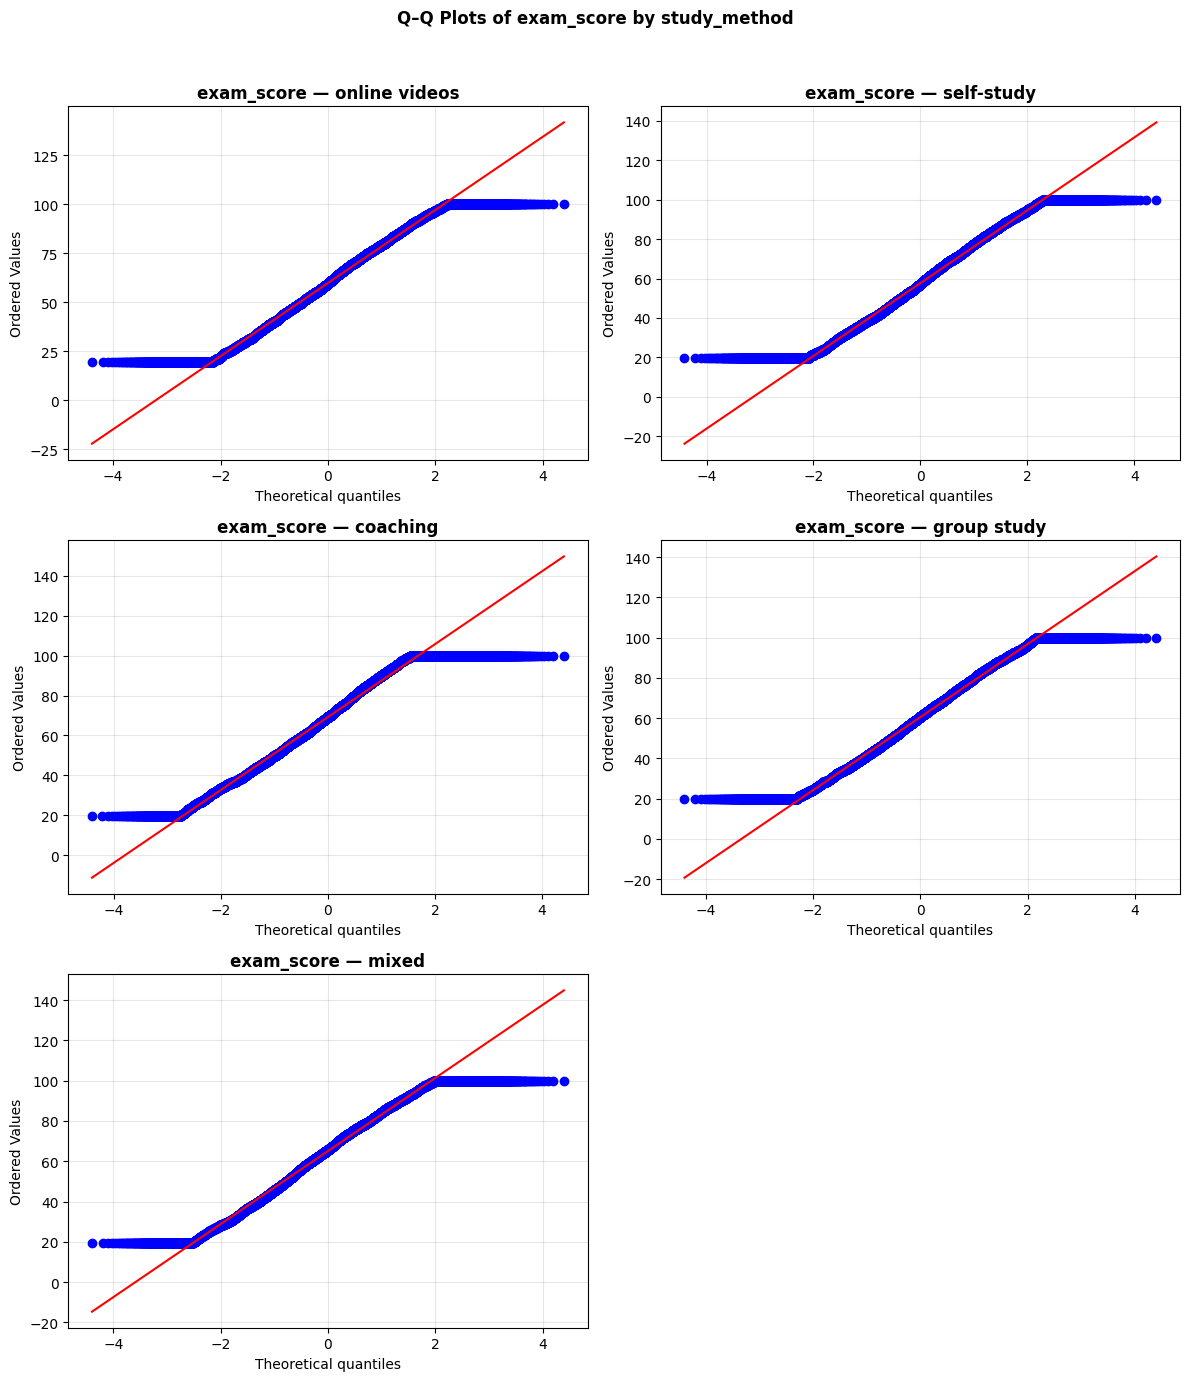

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,coaching,-0.1390,-0.6966,"Approximately symmetric, Normal tails"
1,exam_score,group study,-0.0040,-0.5786,"Approximately symmetric, Normal tails"
2,exam_score,mixed,-0.1816,-0.5617,"Approximately symmetric, Normal tails"
3,exam_score,online videos,-0.0207,-0.5953,"Approximately symmetric, Normal tails"
4,exam_score,self-study,0.0717,-0.6076,"Approximately symmetric, Normal tails"


2026-01-02 12:24:18 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:18 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:18 | DEBUG | Number of groups detected: 5


,Metric,Value
0,Levene’s Statistic,63.8020
1,p-value,0.000000
2,Max/Min Variance Ratio,1.06


2026-01-02 12:24:18 | INFO | Interpretation:
2026-01-02 12:24:18 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:18 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:18 | INFO | Running Welch’s ANOVA Test: exam_score ~ study_method
2026-01-02 12:24:18 | DEBUG | Number of groups detected: 5
2026-01-02 12:24:18 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:24:19 | INFO | Welch ANOVA F-statistic: 8443.8121
2026-01-02 12:24:19 | INFO | p-value: 0.000000
2026-01-02 12:24:19 | DEBUG | Welch ANOVA table:
         Source  ddof1          ddof2           F  p-unc       np2
0  study_method      4  324404.310214  8443.81209    0.0  0.049572
2026-01-02 12:24:19 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:24:19 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:24:19 | DEBUG | Running Games

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,coaching,group study,69.2454,60.5453,8.7001,0.0716,121.5311,261861.7355,0.0000,0.4743
1,coaching,mixed,69.2454,65.0754,4.1700,0.0716,58.2638,261929.1291,0.0000,0.2274
2,coaching,online videos,69.2454,59.7414,9.5040,0.0729,130.4254,258469.2501,0.0000,0.5114
3,coaching,self-study,69.2454,57.7312,11.5142,0.0711,161.9143,270910.7403,0.0000,0.6221
4,group study,mixed,60.5453,65.0754,-4.5301,0.0723,-62.6181,253908.8941,0.0000,-0.2485
5,group study,online videos,60.5453,59.7414,0.8039,0.0736,10.9182,251647.0458,0.0000,0.0435
6,group study,self-study,60.5453,57.7312,2.8141,0.0719,39.1433,261616.0629,0.0000,0.1529
7,mixed,online videos,65.0754,59.7414,5.3340,0.0736,72.4595,251682.4863,0.0000,0.2887
8,mixed,self-study,65.0754,57.7312,7.3442,0.0719,102.1794,261679.9431,0.0000,0.3991
9,online videos,self-study,59.7414,57.7312,2.0102,0.0732,27.4733,258444.3960,0.0000,0.1078


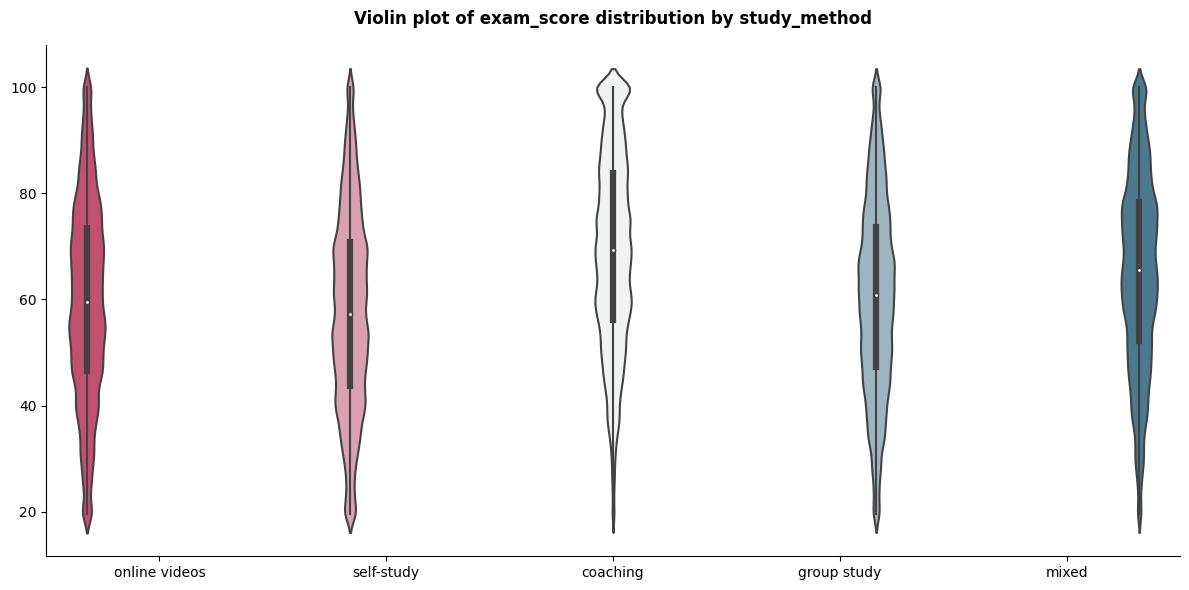

,facility_rating,Count,Mean,Median,Std
0,high,210142,66.690123,67.300000,18.527005
1,medium,220842,63.021764,63.100000,18.635646
2,low,219016,57.973937,58.300000,18.570728


2026-01-02 12:24:21 | INFO | Checking normality of feature 'exam_score' by groups of 'facility_rating'...
2026-01-02 12:24:21 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:24:21 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:21 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:24:22 | DEBUG | [facility_rating=high] skew=-0.1044, kurtosis=-0.6843 → Approximately symmetric, Normal tails
2026-01-02 12:24:22 | DEBUG | [facility_rating=low] skew=0.0024, kurtosis=-0.5964 → Approximately symmetric, Normal tails
2026-01-02 12:24:22 | DEBUG | [facility_rating=medium] skew=-0.0475, kurtosis=-0.6120 → Approximately symmetric, Normal tails
2026-01-02 12:24:22 | INFO | Generating Q–Q plots for visual assessment...


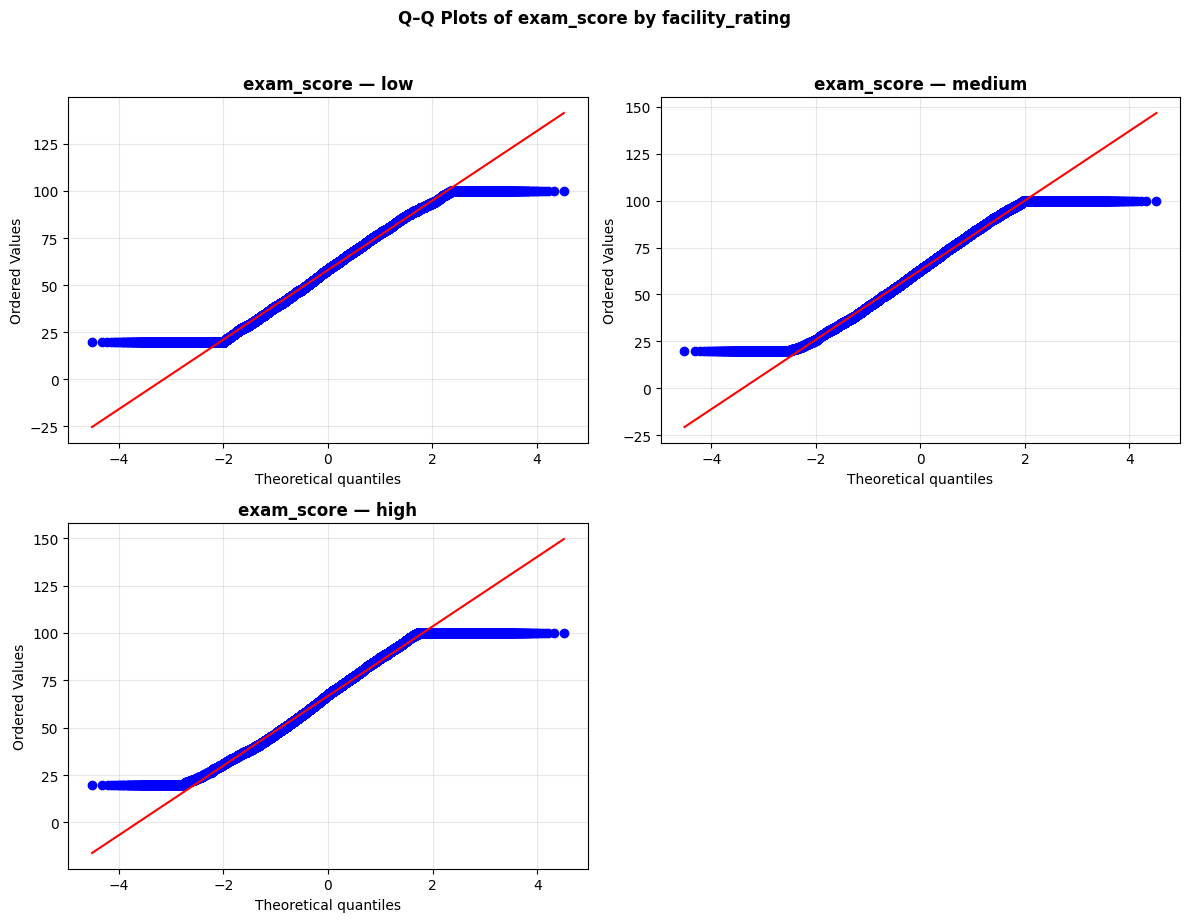

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,high,-0.1044,-0.6843,"Approximately symmetric, Normal tails"
1,exam_score,low,0.0024,-0.5964,"Approximately symmetric, Normal tails"
2,exam_score,medium,-0.0475,-0.6120,"Approximately symmetric, Normal tails"


2026-01-02 12:24:24 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:24 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:24 | DEBUG | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,3.4325
1,p-value,0.032307
2,Max/Min Variance Ratio,1.01


2026-01-02 12:24:24 | INFO | Interpretation:
2026-01-02 12:24:24 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:24 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:24 | INFO | Running Welch’s ANOVA Test: exam_score ~ facility_rating
2026-01-02 12:24:24 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:24 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:24:25 | INFO | Welch ANOVA F-statistic: 11965.4804
2026-01-02 12:24:25 | INFO | p-value: 0.000000
2026-01-02 12:24:25 | DEBUG | Welch ANOVA table:
            Source  ddof1          ddof2             F  p-unc      np2
0  facility_rating      2  432929.049415  11965.480419    0.0  0.03541
2026-01-02 12:24:25 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:24:25 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:24:25 | DEBUG | R

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,high,low,66.6901,57.9739,8.7162,0.0566,153.8881,428503.9929,0.0000,0.4699
1,high,medium,66.6901,63.0218,3.6684,0.0566,64.7875,430155.8865,0.0000,0.1974
2,low,medium,57.9739,63.0218,-5.0478,0.0561,-89.9792,439845.8103,0.0000,-0.2713


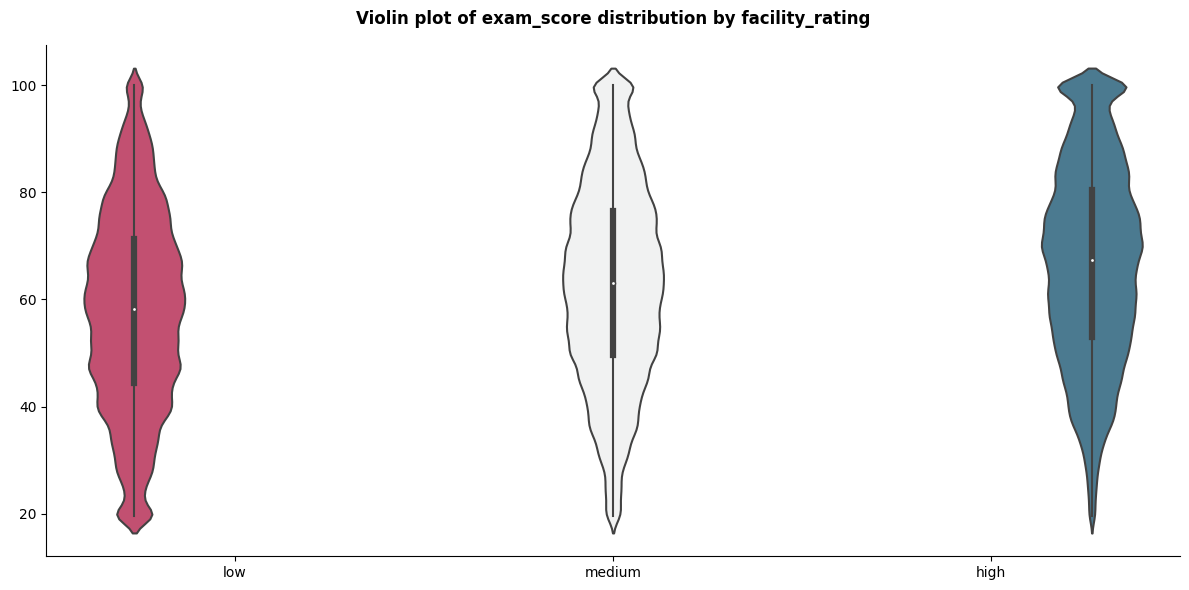

,exam_difficulty,Count,Mean,Median,Std
0,hard,103459,62.670073,62.800000,19.131962
1,moderate,363860,62.604464,62.500000,18.955807
2,easy,182681,62.220069,62.500000,18.711728


2026-01-02 12:24:27 | INFO | Checking normality of feature 'exam_score' by groups of 'exam_difficulty'...
2026-01-02 12:24:27 | INFO | Evaluating distribution characteristics (skewness & kurtosis)...
2026-01-02 12:24:27 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:27 | DEBUG | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-01-02 12:24:27 | DEBUG | [exam_difficulty=easy] skew=-0.0468, kurtosis=-0.5809 → Approximately symmetric, Normal tails
2026-01-02 12:24:27 | DEBUG | [exam_difficulty=hard] skew=-0.0658, kurtosis=-0.6545 → Approximately symmetric, Normal tails
2026-01-02 12:24:27 | DEBUG | [exam_difficulty=moderate] skew=-0.0446, kurtosis=-0.6275 → Approximately symmetric, Normal tails
2026-01-02 12:24:27 | INFO | Generating Q–Q plots for visual assessment...


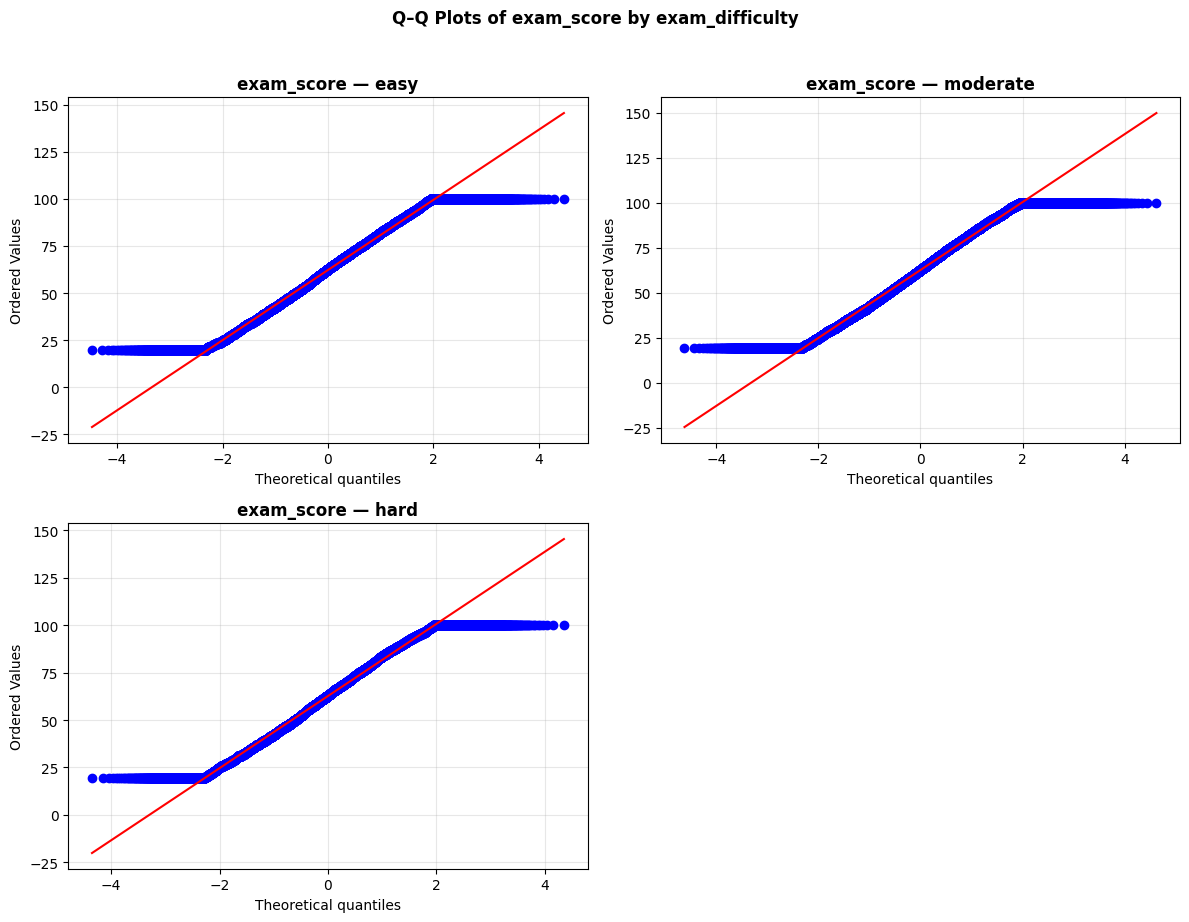

,Feature,Group,Skewness,Kurtosis,Remark
0,exam_score,easy,-0.0468,-0.5809,"Approximately symmetric, Normal tails"
1,exam_score,hard,-0.0658,-0.6545,"Approximately symmetric, Normal tails"
2,exam_score,moderate,-0.0446,-0.6275,"Approximately symmetric, Normal tails"


2026-01-02 12:24:30 | INFO | All groups approximately follow a normal distribution.
2026-01-02 12:24:30 | INFO | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-01-02 12:24:30 | DEBUG | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,50.4969
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05


2026-01-02 12:24:30 | INFO | Interpretation:
2026-01-02 12:24:30 | INFO | - Status: Statistically different variances, but practical difference is small.
2026-01-02 12:24:30 | INFO | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-01-02 12:24:30 | INFO | Running Welch’s ANOVA Test: exam_score ~ exam_difficulty
2026-01-02 12:24:30 | DEBUG | Number of groups detected: 3
2026-01-02 12:24:30 | INFO | Assessing mean differences under heteroscedastic conditions...
2026-01-02 12:24:30 | INFO | Welch ANOVA F-statistic: 30.0389
2026-01-02 12:24:30 | INFO | p-value: 0.000000
2026-01-02 12:24:30 | DEBUG | Welch ANOVA table:
            Source  ddof1          ddof2          F         p-unc       np2
0  exam_difficulty      2  261109.201947  30.038915  9.031617e-14  0.000091
2026-01-02 12:24:30 | INFO | Result: p-value < 0.05 → Reject H0
2026-01-02 12:24:30 | INFO | Conclusion: Significant mean differences detected.
2026-01-02 12:24:30 | DE

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,easy,hard,62.2201,62.6701,-0.4500,0.0739,-6.0931,210866.1623,0.0000,-0.0239
1,easy,moderate,62.2201,62.6045,-0.3844,0.0539,-7.1329,370099.0767,0.0000,-0.0204
2,hard,moderate,62.6701,62.6045,0.0656,0.0673,0.9753,165605.4143,0.5925,0.0035


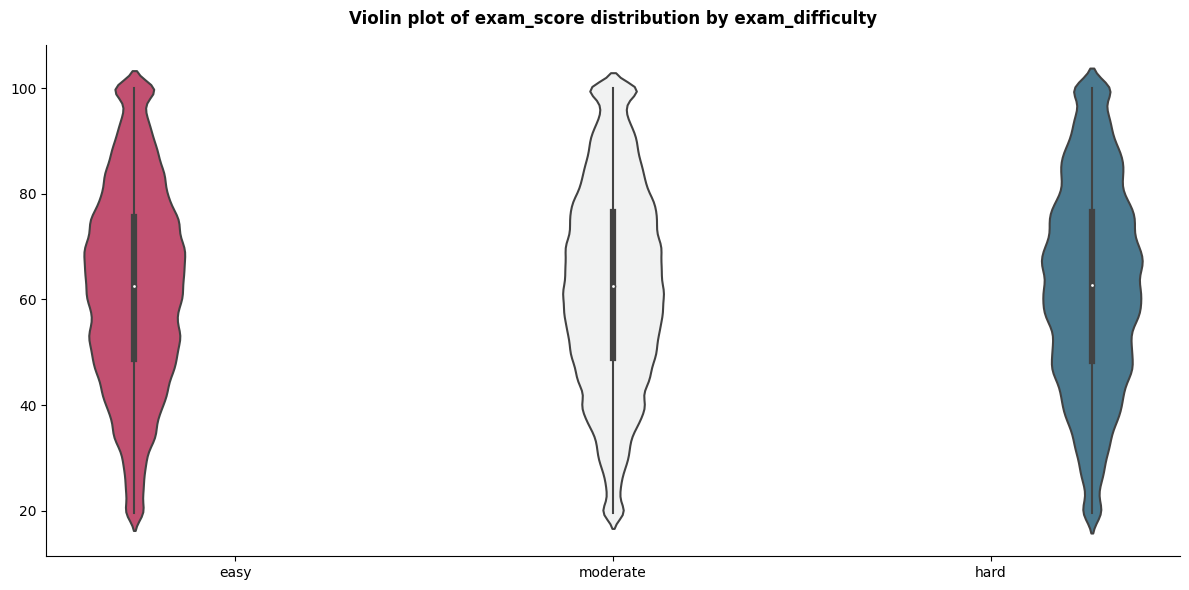

In [21]:
def perform_statical_testing(target_feature: str, feature: str = config.target_feature, df: pd.DataFrame = df_train_combined) -> None:
    """
    Perform statistical tests to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(target_feature: str, feature: str = config.target_feature, df: pd.DataFrame = df_train_combined,
                                order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(12, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique(), tone="diverging"))
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", fontsize=12, pad=15, weight="bold")
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in cat_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by {config.target_feature}</b></h2>"))
    plot_numerical_distribution(df = df_train_combined, target_feature=feature)

**Insight Categorical Features vs Exam Score**

`gender` <br>
Exam performance is broadly consistent across genders; observed differences mainly reflect the large sample size.

`course` <br>
Exam performance is broadly consistent across courses; statistically significant differences reflect large sample size rather than meaningful academic gaps.

`internet_access` <br>
Exam performance does not differ between students with and without internet access.

`sleep_quality` <br>
Sleep quality shows a statistically significant and practically meaningful impact on exam performance.

`study_method` <br>
Study method has a meaningful impact on exam performance, with coached and mixed approaches yielding substantially higher scores.

`facility_rating` <br>
Better facility quality is associated with higher exam scores, though its impact is moderate compared to other factors.

`exam_difficulty` <br>
Exam difficulty shows statistically detectable but practically negligible differences in exam scores.

## Overal Picuture

| Feature              | Type        | Relationship with `exam_score`          | Statistical Significance  | Practical Impact | Key Interpretation                                                                     |
| -------------------- | ----------- | --------------------------------------- | ------------------------- | ---------------- | -------------------------------------------------------------------------------------- |
| **study_hours**      | Numerical   | **Strong positive** (ρ ≈ +0.72 → +0.76) | Significant               | **High**         | Most influential linear predictor; increased study time strongly improves exam scores. |
| **class_attendance** | Numerical   | Moderate positive (ρ ≈ +0.31 → +0.36)   | Significant               | Medium           | Regular attendance meaningfully supports better performance.                           |
| **sleep_hours**      | Numerical   | Weak positive (ρ ≈ +0.13 → +0.17)       | Significant               | Low              | Adequate sleep is beneficial, but linear effect is limited.                            |
| **age**              | Numerical   | Near zero correlation                   | Not significant           | None             | Age does not directly influence exam performance.                                      |
| **gender**           | Categorical | No meaningful difference                | Statistically significant | Negligible       | Observed differences driven by large sample size rather than true performance gaps.    |
| **course**           | Categorical | Small differences across groups         | Statistically significant | Negligible       | Course-related score differences are not academically meaningful.                      |
| **internet_access**  | Categorical | No difference                           | Not significant           | None             | Internet access alone does not affect exam outcomes.                                   |
| **sleep_quality**    | Categorical | Clear group separation                  | Significant               | **Medium–High**  | Better sleep quality has a meaningful and practical impact on scores.                  |
| **study_method**     | Categorical | Large group differences                 | Significant               | **High**         | Coached and mixed study methods substantially outperform self-study alone.             |
| **facility_rating**  | Categorical | Positive trend                          | Significant               | Medium           | Better facilities are associated with higher exam scores.                              |
| **exam_difficulty**  | Categorical | Small score differences                 | Significant               | Very Low         | Differences are detectable statistically but negligible in practice.                   |

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Feature Engineering

In [22]:
BASE = [col for col in df_train_combined.columns if col not in ["id", config.target_feature]]
logger.info("--- Creating Interaction Features ---")
inter_start = time.time()

INTER = []
for col1, col2 in combinations(BASE, 2):
    new_col = f"{col1}_{col2}"
    INTER.append(new_col)
    df_train_combined[new_col] = df_train_combined[col1].astype(str) + "_" + df_train_combined[col2].astype(str)
    df_test[new_col] = df_test[col1].astype(str) + "_" + df_test[col2].astype(str)

logger.info(f"Created {len(INTER)} interaction features in {time.time() - inter_start:.2f}s")

2026-01-02 12:24:34 | INFO | --- Creating Interaction Features ---
2026-01-02 12:25:02 | INFO | Created 55 interaction features in 28.58s


In [23]:
logger.info("--- Leak-Proof Target Encoding Aggregations ---")
agg_start = time.time()

FEATURES_TO_AGGREGATE = cat_features
AGG_FEATURES = []

# Initialize columns
for col in FEATURES_TO_AGGREGATE:
    df_train_combined[f"TE_MEAN_{col}"] = np.nan
    df_train_combined[f"TE_STD_{col}"] = np.nan
    AGG_FEATURES.extend([f"TE_MEAN_{col}", f"TE_STD_{col}"])

logger.info(f"Aggregating {len(FEATURES_TO_AGGREGATE)} features over {config.fold} folds...")

# K-Fold aggregation (leak-proof)
kf = KFold(n_splits=config.fold, shuffle=True, random_state=config.random_state)

for fold, (train_idx, val_idx) in enumerate(kf.split(df_train_combined), 1):
    logger.debug(f"  Processing Fold {fold}/{config.fold}...")

    X_train_fold = df_train_combined.iloc[train_idx]
    
    for col in FEATURES_TO_AGGREGATE:
        # Calculate stats on training fold only
        agg_stats = X_train_fold.groupby(col)[config.target_feature].agg(["mean", "std"])

        # Map to validation fold
        df_train_combined.loc[val_idx, f"TE_MEAN_{col}"] = df_train_combined.loc[val_idx, col].map(agg_stats["mean"]).values
        df_train_combined.loc[val_idx, f"TE_STD_{col}"] = df_train_combined.loc[val_idx, col].map(agg_stats["std"]).values

# Calculate final aggregations for test set
logger.info("  Calculating aggregations for test set...")
for col in FEATURES_TO_AGGREGATE:
    agg_stats_full = df_train_combined.groupby(col)[config.target_feature].agg(["mean", "std"])
    df_test[f"TE_MEAN_{col}"] = df_test[col].map(agg_stats_full["mean"])
    df_test[f"TE_STD_{col}"] = df_test[col].map(agg_stats_full["std"])

# Fill NaNs with global stats
global_mean = df_train_combined[config.target_feature].mean()
global_std = df_train_combined[config.target_feature].std()
df_train_combined[AGG_FEATURES] = df_train_combined[AGG_FEATURES].fillna(global_mean)
df_test[AGG_FEATURES] = df_test[AGG_FEATURES].fillna(global_mean)

logger.info(f"Created {len(AGG_FEATURES)} aggregation features in {time.time() - agg_start:.2f}s")

2026-01-02 12:25:02 | INFO | --- Leak-Proof Target Encoding Aggregations ---
2026-01-02 12:25:03 | INFO | Aggregating 7 features over 5 folds...
2026-01-02 12:25:03 | DEBUG |   Processing Fold 1/5...
2026-01-02 12:25:04 | DEBUG |   Processing Fold 2/5...
2026-01-02 12:25:05 | DEBUG |   Processing Fold 3/5...
2026-01-02 12:25:07 | DEBUG |   Processing Fold 4/5...
2026-01-02 12:25:08 | DEBUG |   Processing Fold 5/5...
2026-01-02 12:25:10 | INFO |   Calculating aggregations for test set...
2026-01-02 12:25:11 | INFO | Created 14 aggregation features in 8.14s


In [24]:
encode_start = time.time()

label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([df_train_combined[col], df_test[col]], ignore_index=True)
    le.fit(combined)
    df_train_combined[col] = le.transform(df_train_combined[col])
    df_test[col] = le.transform(df_test[col])
    label_encoders[col] = le

logger.info(f"Encoded {len(cat_features)} categorical features in {time.time() - encode_start:.2f}s")

2026-01-02 12:25:12 | INFO | Encoded 7 categorical features in 1.31s


In [25]:
FEATURES = BASE + AGG_FEATURES + INTER

logger.info(f"--- Feature Summary ---")
logger.info(f"Total Features: {len(FEATURES)}")
logger.info(f"Base Features: {len(BASE)}")
logger.info(f"Target Encoding Aggregations: {len(AGG_FEATURES)}")
logger.info(f"Interaction Features: {len(INTER)}")

X = df_train_combined[FEATURES].copy()
y = df_train_combined[config.target_feature].copy()
X_test = df_test[FEATURES].copy()

logger.info(f"Training data shape: {X.shape}")
logger.info(f"Test data shape: {X_test.shape}")

2026-01-02 12:25:12 | INFO | --- Feature Summary ---
2026-01-02 12:25:12 | INFO | Total Features: 80
2026-01-02 12:25:12 | INFO | Base Features: 11
2026-01-02 12:25:12 | INFO | Target Encoding Aggregations: 14
2026-01-02 12:25:12 | INFO | Interaction Features: 55
2026-01-02 12:25:17 | INFO | Training data shape: (650000, 80)
2026-01-02 12:25:17 | INFO | Test data shape: (270000, 80)


In [26]:
encode_start = time.time()
logger.info(f"--- Reduce memory usage ---")

# Display information about the DataFrames before optimization
logger.debug(f"Memory usage of train data before optimization: {config.memory_report(df_train_combined)}")
logger.debug(f"Memory usage of test data before optimization: {config.memory_report(df_test)}")

df_train_combined = config.reduce_mem_usage(df_train_combined)
df_test = config.reduce_mem_usage(df_test)

# Display information about the DataFrames after optimization
logger.debug(f"Memory usage of train data after optimization: {config.memory_report(df_train_combined)}")
logger.debug(f"Memory usage of test data after optimization: {config.memory_report(df_test)}")

logger.info(f"Optimization memory usage for train and test data in {time.time() - encode_start:.2f}s")

2026-01-02 12:25:18 | INFO | --- Reduce memory usage ---
2026-01-02 12:25:24 | DEBUG | Memory usage of train data before optimization: 2417.0168228149414
2026-01-02 12:25:27 | DEBUG | Memory usage of test data before optimization: 1001.9392509460449
2026-01-02 12:25:33 | DEBUG | Memory usage of train data after optimization: 139.3386402130127
2026-01-02 12:25:33 | DEBUG | Memory usage of test data after optimization: 67.33986186981201
2026-01-02 12:25:33 | INFO | Optimization memory usage for train and test data in 15.26s


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Define Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Define Metric
    </h1>
</div>

**Root Mean Squared Error (RMSE)**

**Definition:**

**RMSE (Root Mean Squared Error)** is a metric used to measure the average deviation between a model’s predicted values and the actual values. The lower the RMSE, the better the model's predictions.

**Formula:**

$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

* $y_i$: Actual value
* $\hat{y}_i$: Predicted value
* $n$: Number of observations

**Characteristics:**

* RMSE is **always non-negative** (≥ 0).
* The closer RMSE is to **0**, the better the model.
* RMSE is **sensitive to outliers** due to squaring the errors.

**References:**

* [Kaggle Evaluation Page](https://www.kaggle.com/discussions/general/215997)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>


**Outer K-Fold (Model-level Cross Validation)**

For each outer fold:

1. **Train / Validation Split**
   - Split dataset into training and validation sets.

2. **Nested K-Fold Target Encoding (Anti-Leakage)**
   - Apply target encoding using an inner K-Fold loop.
   - Ensure validation data is never used to compute encoding statistics.

3. **Drop Raw Interaction Columns**
   - Remove original categorical or interaction columns
   - Keep only encoded / engineered features.

4. **Train LightGBM Model**
   - Train the model on the encoded training set.

5. **Generate Predictions**
   - Predict:
     - Out-of-Fold (OOF) predictions for validation data
     - Averaged predictions for the test set

6. **Log Metrics**
   - Record fold-level performance metrics (e.g. RMSE, MAE)
   - Track training time and model parameters if needed

In [27]:
def plot_prediction_diagnostics(y_true, y_pred, fold=None):
    """
    Plot Predicted vs Actual and Residual Plot side-by-side
    for validation diagnostics.
    """

    residuals = y_true - y_pred

    # Create subplots
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Predicted vs Actual
    ax[0].scatter(y_true, y_pred, alpha=0.4, color="royalblue", edgecolors="none", rasterized=True, s=8)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax[0].plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        linewidth=2,
        label="Perfect Prediction (y = x)"
    )

    ax[0].set_xlabel("Actual Values")
    ax[0].set_ylabel("Predicted Values")
    title_1 = "Predicted vs Actual (Validation Set)"
    if fold is not None:
        title_1 += f" — Fold {fold}"
    ax[0].set_title(title_1, weight="bold", fontsize=12, pad=15)
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # Residual Plot
    ax[1].scatter(y_true, residuals, alpha=0.4, color="royalblue", edgecolors="none", rasterized=True, s=8)
    ax[1].axhline(0, color="red", linestyle="--", linewidth=2)

    ax[1].set_xlabel("Actual Values")
    ax[1].set_ylabel("Residuals (Actual − Predicted)")
    title_2 = "Residual Plot"
    if fold is not None:
        title_2 += f" — Fold {fold}"
    ax[1].set_title(title_2, weight="bold", fontsize=12, pad=15)
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

2026-01-02 12:25:34 | INFO | ------------------------------------------------------------
2026-01-02 12:25:34 | INFO | Fold 1/5
2026-01-02 12:25:34 | INFO | ------------------------------------------------------------
2026-01-02 12:25:36 | INFO | Target Encoding interaction features...
2026-01-02 12:25:42 | DEBUG | Encoded 10/55 columns...
2026-01-02 12:25:47 | DEBUG | Encoded 20/55 columns...
2026-01-02 12:25:57 | DEBUG | Encoded 30/55 columns...
2026-01-02 12:26:04 | DEBUG | Encoded 40/55 columns...
2026-01-02 12:26:09 | DEBUG | Encoded 50/55 columns...
2026-01-02 12:26:13 | INFO | Target encoding completed in 36.79s
2026-01-02 12:26:13 | INFO | Training LightGBM...
2026-01-02 12:28:51 | INFO | Training completed in 158.16s


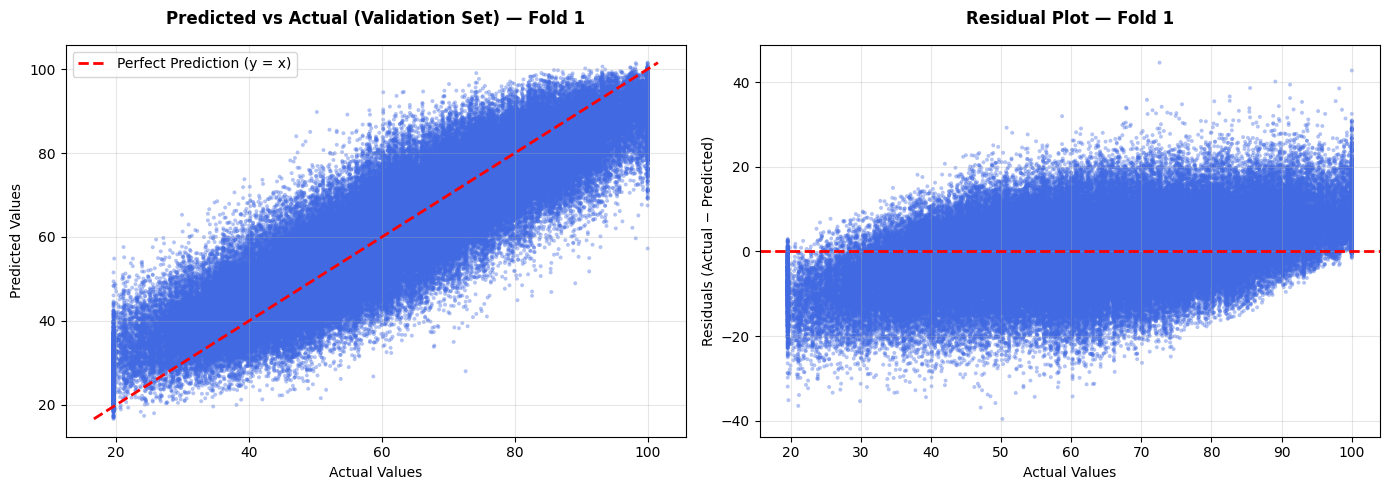

2026-01-02 12:29:15 | INFO | Fold 1 Results:
2026-01-02 12:29:15 | INFO | RMSE: 8.7198
2026-01-02 12:29:15 | INFO | Time: 221.29s (TE: 36.79s, Model: 158.16s)
2026-01-02 12:29:15 | INFO | ------------------------------------------------------------
2026-01-02 12:29:15 | INFO | Fold 2/5
2026-01-02 12:29:15 | INFO | ------------------------------------------------------------
2026-01-02 12:29:17 | INFO | Target Encoding interaction features...
2026-01-02 12:29:23 | DEBUG | Encoded 10/55 columns...
2026-01-02 12:29:28 | DEBUG | Encoded 20/55 columns...
2026-01-02 12:29:38 | DEBUG | Encoded 30/55 columns...
2026-01-02 12:29:44 | DEBUG | Encoded 40/55 columns...
2026-01-02 12:29:50 | DEBUG | Encoded 50/55 columns...
2026-01-02 12:29:53 | INFO | Target encoding completed in 36.00s
2026-01-02 12:29:53 | INFO | Training LightGBM...
2026-01-02 12:32:16 | INFO | Training completed in 142.92s


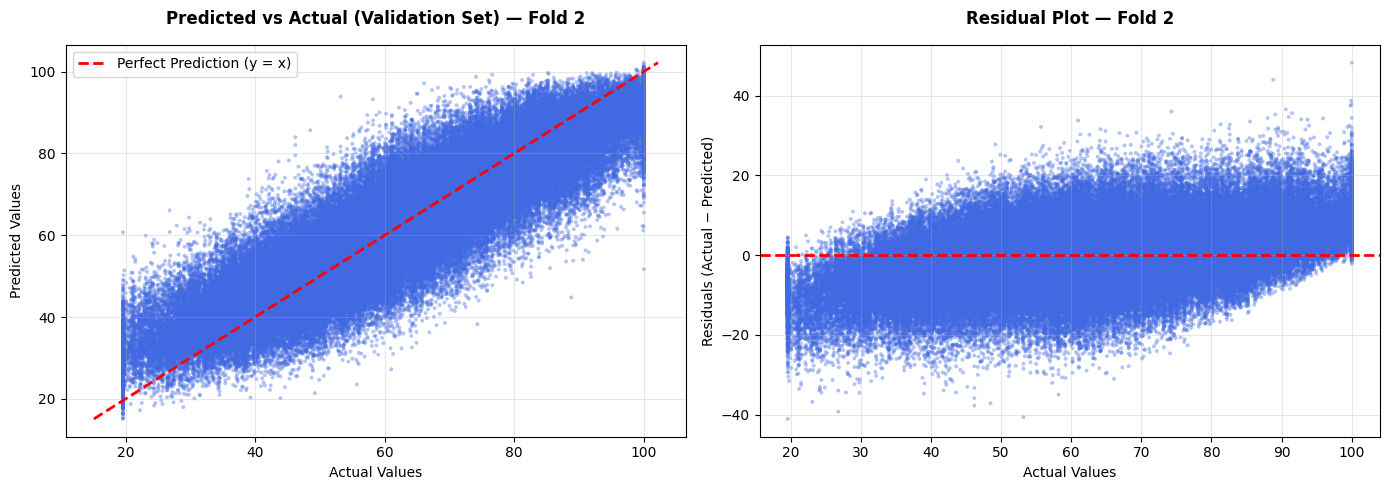

2026-01-02 12:32:35 | INFO | Fold 2 Results:
2026-01-02 12:32:35 | INFO | RMSE: 8.7370
2026-01-02 12:32:35 | INFO | Time: 200.17s (TE: 36.00s, Model: 142.92s)
2026-01-02 12:32:35 | INFO | ------------------------------------------------------------
2026-01-02 12:32:35 | INFO | Fold 3/5
2026-01-02 12:32:36 | INFO | ------------------------------------------------------------
2026-01-02 12:32:37 | INFO | Target Encoding interaction features...
2026-01-02 12:32:43 | DEBUG | Encoded 10/55 columns...
2026-01-02 12:32:48 | DEBUG | Encoded 20/55 columns...
2026-01-02 12:32:58 | DEBUG | Encoded 30/55 columns...
2026-01-02 12:33:05 | DEBUG | Encoded 40/55 columns...
2026-01-02 12:33:10 | DEBUG | Encoded 50/55 columns...
2026-01-02 12:33:13 | INFO | Target encoding completed in 36.26s
2026-01-02 12:33:13 | INFO | Training LightGBM...
2026-01-02 12:35:30 | INFO | Training completed in 136.98s


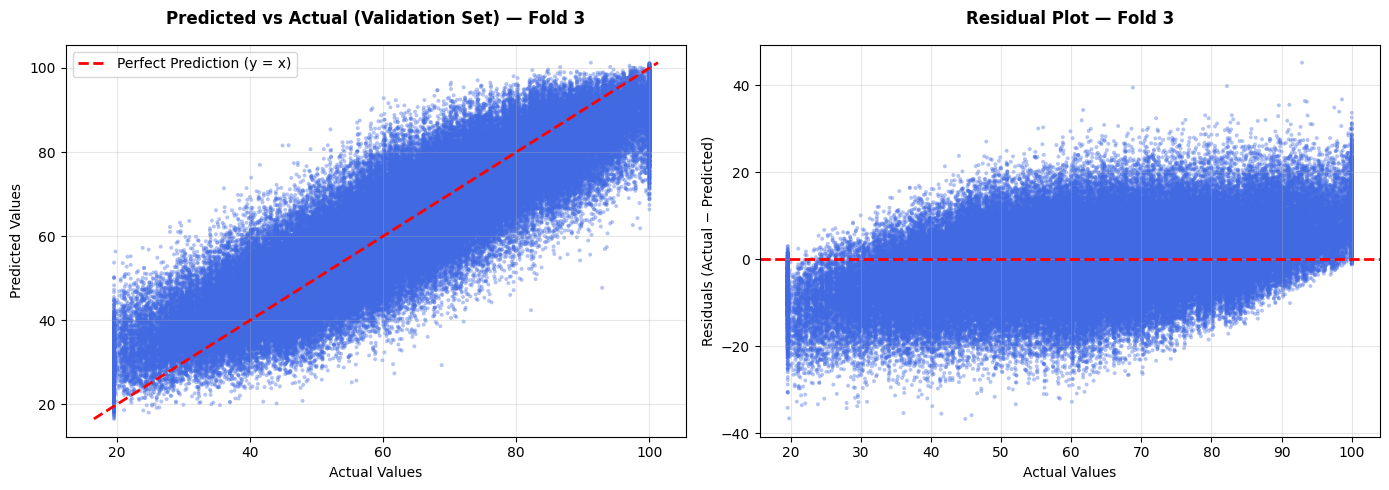

2026-01-02 12:35:49 | INFO | Fold 3 Results:
2026-01-02 12:35:49 | INFO | RMSE: 8.7278
2026-01-02 12:35:49 | INFO | Time: 193.31s (TE: 36.26s, Model: 136.98s)
2026-01-02 12:35:49 | INFO | ------------------------------------------------------------
2026-01-02 12:35:49 | INFO | Fold 4/5
2026-01-02 12:35:49 | INFO | ------------------------------------------------------------
2026-01-02 12:35:51 | INFO | Target Encoding interaction features...
2026-01-02 12:35:56 | DEBUG | Encoded 10/55 columns...
2026-01-02 12:36:02 | DEBUG | Encoded 20/55 columns...
2026-01-02 12:36:11 | DEBUG | Encoded 30/55 columns...
2026-01-02 12:36:18 | DEBUG | Encoded 40/55 columns...
2026-01-02 12:36:23 | DEBUG | Encoded 50/55 columns...
2026-01-02 12:36:27 | INFO | Target encoding completed in 35.96s
2026-01-02 12:36:27 | INFO | Training LightGBM...
2026-01-02 12:38:48 | INFO | Training completed in 141.78s


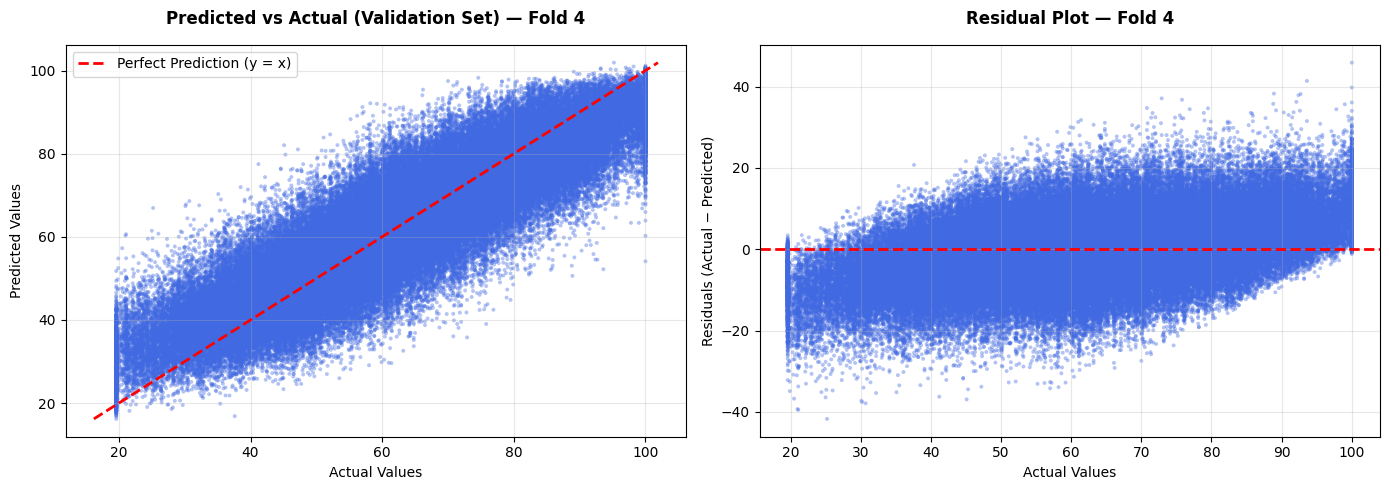

2026-01-02 12:39:09 | INFO | Fold 4 Results:
2026-01-02 12:39:09 | INFO | RMSE: 8.7467
2026-01-02 12:39:09 | INFO | Time: 200.35s (TE: 35.96s, Model: 141.78s)
2026-01-02 12:39:09 | INFO | ------------------------------------------------------------
2026-01-02 12:39:09 | INFO | Fold 5/5
2026-01-02 12:39:09 | INFO | ------------------------------------------------------------
2026-01-02 12:39:11 | INFO | Target Encoding interaction features...
2026-01-02 12:39:17 | DEBUG | Encoded 10/55 columns...
2026-01-02 12:39:22 | DEBUG | Encoded 20/55 columns...
2026-01-02 12:39:32 | DEBUG | Encoded 30/55 columns...
2026-01-02 12:39:38 | DEBUG | Encoded 40/55 columns...
2026-01-02 12:39:44 | DEBUG | Encoded 50/55 columns...
2026-01-02 12:39:47 | INFO | Target encoding completed in 36.42s
2026-01-02 12:39:47 | INFO | Training LightGBM...
2026-01-02 12:42:11 | INFO | Training completed in 143.13s


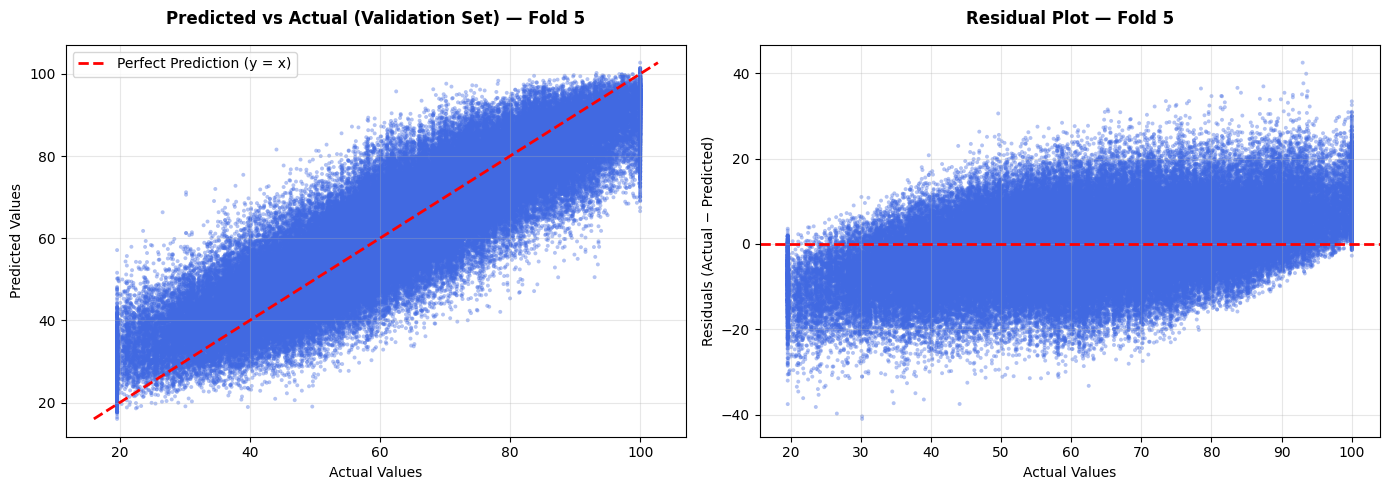

2026-01-02 12:42:29 | INFO | Fold 5 Results:
2026-01-02 12:42:29 | INFO | RMSE: 8.7342
2026-01-02 12:42:29 | INFO | Time: 200.20s (TE: 36.42s, Model: 143.13s)


In [28]:
# Initialize containers
oof_preds = np.zeros(len(X))        # Out-of-fold predictions
test_preds = np.zeros(len(X_test))  # Averaged test predictions
fold_scores = []
fold_times = []
fold_models = []

kf = KFold(n_splits=config.fold, shuffle=True, random_state=config.random_state)

# Outer K-Fold loop (model CV)
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    logger.info("-" * 60)
    logger.info(f"Fold {fold}/{config.fold}")
    logger.info("-" * 60)
    fold_start = time.time()

    # Split data for current fold
    X_train_fold = X.iloc[train_idx].copy()
    X_val_fold = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    X_test_fold = X_test.copy()

    # Nested Target Encoding
    logger.info("Target Encoding interaction features...")
    te_start = time.time()
    
    # Inner CV to prevent leakage in target encoding
    te_kf = KFold(n_splits=config.fold, shuffle=True, random_state=config.random_state)
    
    # Pre-create encoded columns
    for col in INTER:
        encoded_col = f"TE_{col}_mean"
        X_train_fold[encoded_col] = 0.0
        X_val_fold[encoded_col] = 0.0
        X_test_fold[encoded_col] = 0.0
    
    # Encode each interaction feature
    for idx, col in enumerate(INTER, 1):
        encoded_col = f"TE_{col}_mean"

        # Inner CV loop for leakage-free encoding
        te_train = np.zeros(len(X_train_fold))
        for te_train_idx, te_val_idx in te_kf.split(X_train_fold):
            te_map = y_train_fold.iloc[te_train_idx].groupby(
                X_train_fold[col].iloc[te_train_idx]
            ).mean()
            te_train[te_val_idx] = X_train_fold[col].iloc[te_val_idx].map(te_map).fillna(
                y_train_fold.iloc[te_train_idx].mean()
            )

        X_train_fold[encoded_col] = te_train

        # Apply encoding to validation and test
        te_map_full = y_train_fold.groupby(X_train_fold[col]).mean()
        global_mean = y_train_fold.mean()

        X_val_fold[encoded_col] = X_val_fold[col].map(te_map_full).fillna(global_mean)
        X_test_fold[encoded_col] = X_test_fold[col].map(te_map_full).fillna(global_mean)
        
        if idx % 10 == 0:
            logger.debug(f"Encoded {idx}/{len(INTER)} columns...")

    # Remove raw interaction columns
    X_train_fold = X_train_fold.drop(columns=INTER)
    X_val_fold = X_val_fold.drop(columns=INTER)
    X_test_fold = X_test_fold.drop(columns=INTER)
    
    te_time = time.time() - te_start
    logger.info(f"Target encoding completed in {te_time:.2f}s")

    # Train LightGBM
    logger.info("Training LightGBM...")
    model_start = time.time()
    
    model = LGBMRegressor(**config.params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[
            __import__("lightgbm").early_stopping(800, verbose=False),
            __import__("lightgbm").log_evaluation(0)
        ]
    )
    
    model_time = time.time() - model_start
    logger.info(f"Training completed in {model_time:.2f}s")

    # Evaluation
    val_preds = model.predict(X_val_fold)
    oof_preds[val_idx] = val_preds
    plot_prediction_diagnostics(y_val_fold, val_preds, fold=fold)
    test_preds += model.predict(X_test_fold) / config.fold

    # Calculate metrics RMSE
    rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))

    fold_scores.append(rmse)
    fold_models.append(model)

    fold_time = time.time() - fold_start
    fold_times.append(fold_time)

    logger.info(f"Fold {fold} Results:")
    logger.info(f"RMSE: {rmse:.4f}")
    logger.info(
        f"Time: {fold_time:.2f}s "
        f"(TE: {te_time:.2f}s, Model: {model_time:.2f}s)"
    )

In [29]:
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))

logger.info(f"Overall OOF RMSE: {overall_rmse:.4f}")
logger.info(f"Mean Fold RMSE: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
logger.info(f"Total Training Time: {sum(fold_times):.2f}s ({sum(fold_times)/60:.2f} min)")

logger.info("Fold-by-Fold Scores:")
for i, (score, t) in enumerate(zip(fold_scores, fold_times), 1):
    logger.debug(f"Fold {i}: RMSE {score:.4f} ({t:.2f}s)")

2026-01-02 12:42:30 | INFO | Overall OOF RMSE: 8.7331
2026-01-02 12:42:30 | INFO | Mean Fold RMSE: 8.7331 (±0.0090)
2026-01-02 12:42:30 | INFO | Total Training Time: 1015.31s (16.92 min)
2026-01-02 12:42:30 | INFO | Fold-by-Fold Scores:
2026-01-02 12:42:30 | DEBUG | Fold 1: RMSE 8.7198 (221.29s)
2026-01-02 12:42:30 | DEBUG | Fold 2: RMSE 8.7370 (200.17s)
2026-01-02 12:42:30 | DEBUG | Fold 3: RMSE 8.7278 (193.31s)
2026-01-02 12:42:30 | DEBUG | Fold 4: RMSE 8.7467 (200.35s)
2026-01-02 12:42:30 | DEBUG | Fold 5: RMSE 8.7342 (200.20s)


2026-01-02 12:42:30 | INFO | --- Top 40 Most Important Features ---


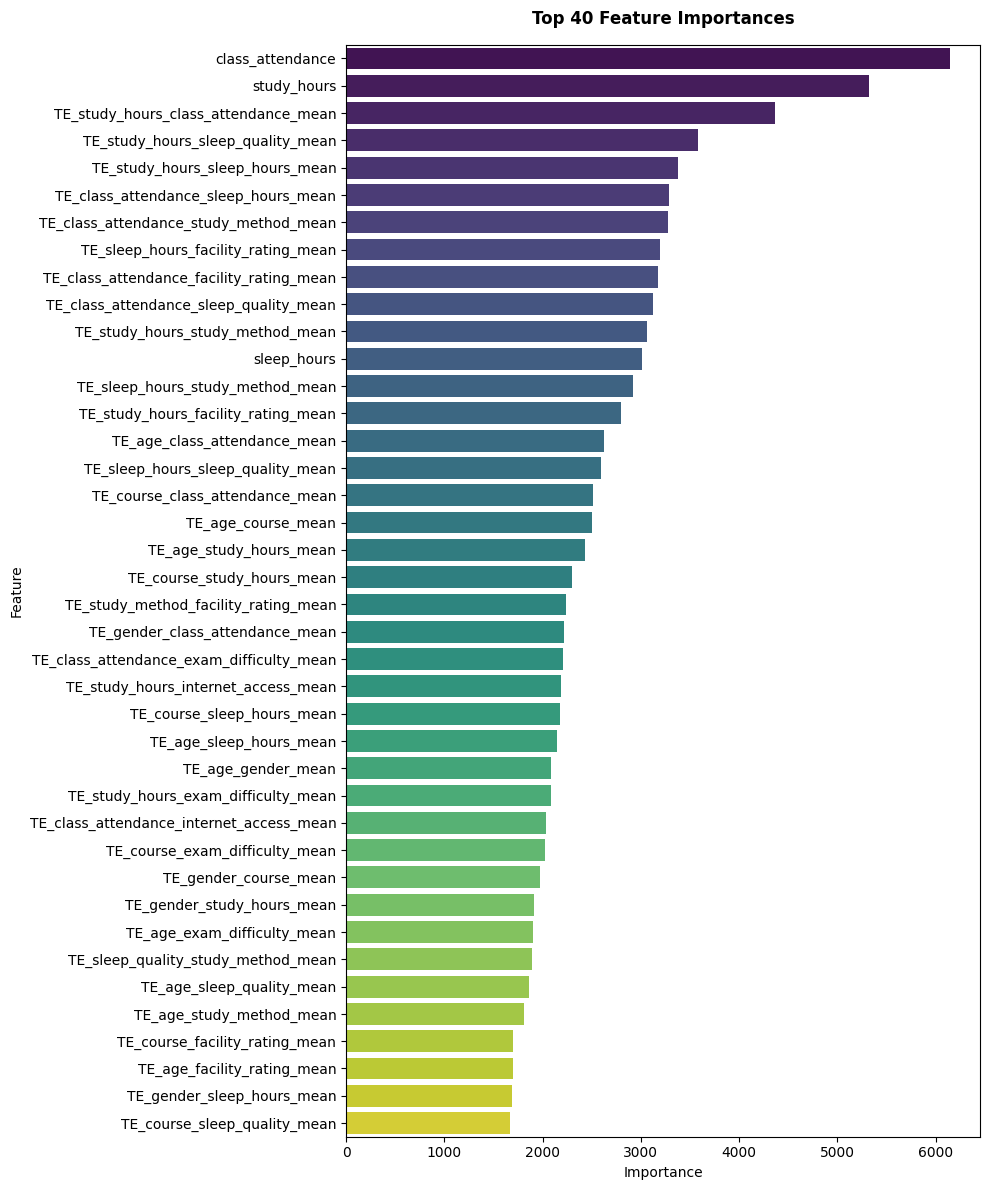

In [30]:
logger.info("--- Top 40 Most Important Features ---")
feature_importance = fold_models[0].feature_importances_
feature_names = fold_models[0].feature_names_in_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance_df.head(40), x="importance", y="feature", palette="viridis")
plt.title("Top 40 Feature Importances", weight="bold", pad=15, fontsize=12)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

2026-01-02 12:42:31 | INFO | --- Creating Submission ---
2026-01-02 12:42:32 | INFO | submission.csv created successfully
2026-01-02 12:42:32 | INFO | Prediction Statistics:
2026-01-02 12:42:32 | DEBUG | Min: 15.81
2026-01-02 12:42:32 | DEBUG | Max: 102.25
2026-01-02 12:42:32 | DEBUG | Mean: 62.54
2026-01-02 12:42:32 | DEBUG | Median: 62.99
2026-01-02 12:42:32 | DEBUG | Std: 16.80
2026-01-02 12:42:32 | INFO | Submission preview:


,id,exam_score
0,630000,70.525667
1,630001,68.062455
2,630002,89.792479
3,630003,56.292214
4,630004,45.722854
5,630005,69.230063
6,630006,72.760096
7,630007,58.657950
8,630008,78.693089
9,630009,91.155436


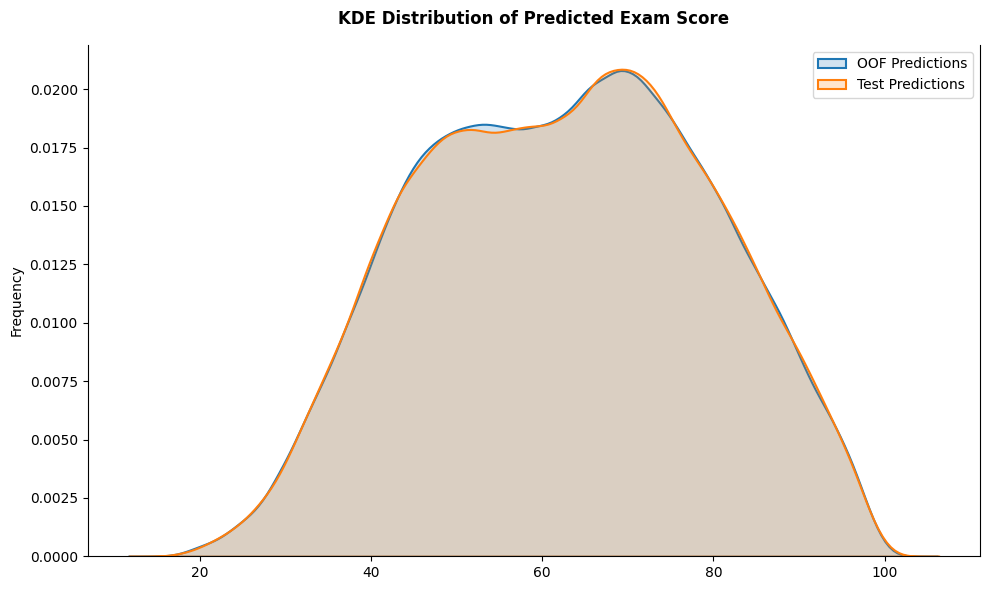

2026-01-02 12:42:36 | INFO | DONE! Ready for submission!
2026-01-02 12:42:36 | INFO | Expected LB Score: ~8.7331 RMSE


In [31]:
logger.info("--- Creating Submission ---")

submission = pd.DataFrame({
    "id": list_test_id,
    config.target_feature: test_preds
})
submission.to_csv("submission.csv", index=False)
logger.info("submission.csv created successfully")

logger.info("Prediction Statistics:")
logger.debug(f"Min: {test_preds.min():.2f}")
logger.debug(f"Max: {test_preds.max():.2f}")
logger.debug(f"Mean: {test_preds.mean():.2f}")
logger.debug(f"Median: {np.median(test_preds):.2f}")
logger.debug(f"Std: {test_preds.std():.2f}")

logger.info("Submission preview:")
display(submission.head(10))

# Plot distribution of predicted probabilities
plt.figure(figsize=(10, 6))
sns.kdeplot(oof_preds, fill=True, linewidth=1.5, alpha=0.2, label="OOF Predictions")
sns.kdeplot(test_preds, fill=True, linewidth=1.5, alpha=0.2, label="Test Predictions")
plt.title("KDE Distribution of Predicted Exam Score", weight="bold", pad=15, fontsize=12)
plt.xlabel("Predicted Exam Score")
sns.despine(left=False, bottom=False, right=False)
plt.ylabel("Frequency")
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()

logger.info("DONE! Ready for submission!")
logger.info(f"Expected LB Score: ~{overall_rmse:.4f} RMSE")

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Conclusion</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Conclusion
    </h1>
</div>

* **Study behavior is the primary driver of exam performance.**
  *Study hours* and *class attendance* not only show strong correlations with exam scores but also rank highest in model feature importance, confirming their central role in both statistical analysis and predictive modeling.

* **Interaction effects amplify core learning factors.**
  Target-encoded interaction features combining *study hours*, *attendance*, *sleep quality*, and *study method* appear frequently among the top important features, indicating that performance depends on **how these behaviors work together**, not on isolated factors.

* **Study method and sleep quality create meaningful performance gaps.**
  Although categorical, these factors exhibit **practically significant impacts**, especially when combined with study time and attendance.

* **Demographic and contextual factors play a minor role.**
  *Gender, age, course, internet access,* and *exam difficulty* may be statistically detectable, but their **practical influence on exam scores is minimal**, acting more as background variables than key drivers.

* **Overall takeaway:**

  > *Exam performance is driven primarily by how students study—time invested, method used, and consistency—while demographic and contextual factors contribute marginally.*

<!-- Google Fonts for Roboto -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #762a83;
    padding: 20px;
    background: linear-gradient(135deg, #e7d4e8, #d9f0d3);
    font-family: 'Roboto', sans-serif;
    box-shadow: 0 4px 8px rgba(0,0,0,0.2);
">
  <h4 style="color:#40004b; font-weight:700; margin-bottom:15px;"> Acknowledgements</h4>
  <p style="font-size:15px; color:#333;"> 
  <a href="https://www.kaggle.com/mahmoudehab6677" style="color:#762a83; text-decoration:underline;">
    @mahmoudehab6677 -
  </a>  
  <a href="https://www.kaggle.com/code/mahmoudehab6677/student-test-scores-predictions" style="color:#762a83; text-decoration:underline;">
    Student Test Scores Predictions
  </a>
</p>

  <h4 style="color:#40004b; font-weight:700; margin-top:30px; margin-bottom:16px;">References</h4>
  <ul style="color:#333; font-size:15px;">
    <li><a href="https://www.kaggle.com/competitions/playground-series-s6e1" style="color:#762a83;">Kaggle Playground Series – S6E1</a></li>
  </ul>

  <h4 style="color:#40004b; font-weight:700; margin-top:30px; margin-bottom:16px;">Citation</h4>
  <p style="font-size:15px; color:#333;">
    Walter Reade and Elizabeth Park. <strong>Predicting Student Test Scores.</strong><br/>
    <a href="https://www.kaggle.com/competitions/playground-series-s6e1" style="color:#762a83; text-decoration:underline;">Kaggle Competition Playground Series S6E1, 2026.</a>
  </p>
</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
